In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import pearsonr, ttest_1samp
from statsmodels.stats.multitest import multipletests

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/AP_empirical_paper1/datasets/shared_helper_modules/')

from config import SPE1_PICKLE_ROOT, CELL_IDS, DICT_CELL_TYPE
from spikewise_plotting import plot_corr_heatmap_only_spk

plt.rcParams['font.family'] = 'Helvetica Neue'

SPE1_PKL = SPE1_PICKLE_ROOT
PVC6_PKL = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles'

SPK_FEATS = ['ramp_amp', 'inflection_time', 'inflection_amp',
              'peak_amp', 'peak_width', 'peak_sharpness',
              'exp_lambda', 'exp_const', 'log_isi']

In [2]:
def compute_within_cell_avg_corr(dfs, feat_cols):
    """Per-cell Pearson r, nanmean across cells, one-sample t-test + FDR.

    Parameters
    ----------
    dfs : list of DataFrames, one per cell
    feat_cols : list of feature column names

    Returns
    -------
    mean_r   : (n, n) average Pearson r across cells
    pval_mat : (n, n) FDR-corrected p-values (one-sample t-test vs 0)
    n_cells  : number of cells that contributed
    """
    n = len(feat_cols)
    cell_mats = []
    for df in dfs:
        sub = df[[c for c in feat_cols if c in df.columns]].dropna()
        if len(sub) < 5:
            continue
        # fill missing features with NaN so matrices align
        sub = sub.reindex(columns=feat_cols)
        r_mat = np.full((n, n), np.nan)
        for i, ci in enumerate(feat_cols):
            for j, cj in enumerate(feat_cols):
                if i == j:
                    r_mat[i, j] = 1.0
                elif ci in sub.columns and cj in sub.columns:
                    _v = sub[[ci, cj]].dropna()
                    if len(_v) > 4:
                        r_mat[i, j], _ = pearsonr(_v[ci], _v[cj])
        cell_mats.append(r_mat)

    if not cell_mats:
        return np.full((n, n), np.nan), np.full((n, n), np.nan), 0

    stack    = np.stack(cell_mats)          # (n_cells, n, n)
    mean_r   = np.nanmean(stack, axis=0)
    np.fill_diagonal(mean_r, 1.0)

    # One-sample t-test per lower-triangle pair against r=0
    lower_idx = [(i, j) for i in range(n) for j in range(i)]
    raw_ps    = []
    for i, j in lower_idx:
        vals = stack[:, i, j]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 2:
            _, p = ttest_1samp(vals, 0)
        else:
            p = 1.0
        raw_ps.append(p)

    _, pvals_fdr, _, _ = multipletests(raw_ps, method='fdr_bh')

    pval_mat = np.ones((n, n))
    for (i, j), pc in zip(lower_idx, pvals_fdr):
        pval_mat[i, j] = pc
        pval_mat[j, i] = pc

    return mean_r, pval_mat, len(cell_mats)


def plot_avg_corr_heatmap(mean_r, pval_mat, feat_cols, title='',
                           corr_threshold=0.1, figsize=(14, 11)):
    """Same aesthetic as plot_corr_heatmap_only_spk but on a pre-averaged matrix."""
    _LABEL = {
        'ramp_amp':        'ramp amp',
        'inflection_time': 'inflec time',
        'inflection_amp':  'inflec amp',
        'peak_amp':        'peak amp',
        'peak_width':      'peak width',
        'peak_sharpness':  'peak sharp',
        'exp_lambda':      'exp lambda',
        'exp_const':       'exp const',
        'log_isi':         'log ISI',
    }
    def _short(f): return _LABEL.get(f, f.replace('_', ' '))
    def _y_label(f):
        s = _short(f)
        parts = s.split(' ')
        return parts[0] + '\n' + parts[1] if len(parts) == 2 else s

    n = len(feat_cols)
    rho_df   = pd.DataFrame(mean_r,   index=feat_cols, columns=feat_cols)
    pval_df  = pd.DataFrame(pval_mat, index=feat_cols, columns=feat_cols)

    mask     = np.triu(np.ones((n, n), dtype=bool))
    xlabels  = [_short(f) for f in feat_cols[:-1]] + ['']
    ylabels  = [''] + [_y_label(f) for f in feat_cols[1:]]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(rho_df, mask=mask, annot=False, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0, ax=ax,
                xticklabels=xlabels, yticklabels=ylabels)

    cbar = ax.collections[0].colorbar
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(['-1', '0', '1'])
    cbar.ax.tick_params(labelsize=22, width=2.5, length=6)
    for spine in cbar.ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(2.5); spine.set_color('#1a1a1a')
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold'); label.set_fontfamily('Helvetica Neue')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(2.5)
        ax.spines[spine].set_color('#1a1a1a')

    _cmap_obj = plt.cm.RdBu_r
    _norm_obj = mcolors.Normalize(vmin=-1, vmax=1)
    cell_h_in = figsize[1] / n
    star_fs   = max(14, int(cell_h_in * 72 * 0.45))
    r_fs      = max(10, int(cell_h_in * 72 * 0.26))

    for i in range(n):
        for j in range(n):
            if i > j:
                r_val = mean_r[i, j]
                p     = pval_mat[i, j]
                sig   = p < 0.05 and abs(r_val) >= corr_threshold
                rgba      = _cmap_obj(_norm_obj(r_val))
                luminance = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
                txt_color = 'white' if luminance < 0.5 else 'black'

                ax.text(j + 0.5, i + 0.68, f'{r_val:.2f}',
                        ha='center', va='center', fontsize=r_fs, color=txt_color,
                        fontweight='bold' if p < 0.05 else 'normal',
                        fontfamily='Helvetica Neue')
                if sig:
                    star = '***' if p < 0.001 else '**' if p < 0.01 else '*'
                    ax.text(j + 0.5, i + 0.32, star,
                            ha='center', va='center', fontsize=star_fs,
                            fontweight='bold', color=txt_color,
                            fontfamily='Helvetica Neue')

    ax.tick_params(axis='x', which='major', labelsize=32, width=2.5)
    ax.tick_params(axis='y', which='major', labelsize=28, width=2.5)
    fig.canvas.draw()
    for label in ax.get_xticklabels():
        label.set_fontweight('bold'); label.set_fontfamily('Helvetica Neue')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold'); label.set_fontfamily('Helvetica Neue')
        label.set_multialignment('center')
    if title:
        ax.set_title(title, fontsize=22, fontweight='bold', fontfamily='Helvetica Neue')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [3]:
# ── pvc-6 ─────────────────────────────────────────────────────────────────────
with open(os.path.join(PVC6_PKL, 'df_all_c1.pkl'), 'rb') as f:
    df_pvc6_c1 = pickle.load(f)
with open(os.path.join(PVC6_PKL, 'df_all_c2.pkl'), 'rb') as f:
    df_pvc6_c2 = pickle.load(f)

# ── spe-1: load per-cell cluster dfs ──────────────────────────────────────────
_cluster_dir = os.path.join(SPE1_PKL, 'cluster_pickles')
dfs_pc   = []
dfs_in   = []
dfs_all  = []
cids_pc  = []
cids_in  = []
cids_all = []

for _cid in CELL_IDS:
    _p = os.path.join(_cluster_dir, f'{_cid}_cluster_df.pkl')
    if not os.path.exists(_p):
        continue
    with open(_p, 'rb') as _f:
        _df = pickle.load(_f)
    _cnum  = int(_cid.replace('c', ''))
    _ctype = DICT_CELL_TYPE.get(_cnum, 'PC')
    dfs_all.append(_df);  cids_all.append(_cid)
    if _ctype == 'IN':
        dfs_in.append(_df);  cids_in.append(_cid)
    else:
        dfs_pc.append(_df);  cids_pc.append(_cid)

print(f'spe-1 — PC: {len(dfs_pc)} cells, IN: {len(dfs_in)} cells, all: {len(dfs_all)} cells')

# ── Find IN and PC cells with most spikes ─────────────────────────────────────
_best_in_idx = int(np.argmax([len(df) for df in dfs_in]))
_best_pc_idx = int(np.argmax([len(df) for df in dfs_pc]))

best_in_cid = cids_in[_best_in_idx]
best_pc_cid = cids_pc[_best_pc_idx]
best_in_df  = dfs_in[_best_in_idx]
best_pc_df  = dfs_pc[_best_pc_idx]

print(f'IN cell with most spikes: {best_in_cid}  ({len(best_in_df)} spikes)')
print(f'PC cell with most spikes: {best_pc_cid}  ({len(best_pc_df)} spikes)')

spe-1 — PC: 37 cells, IN: 6 cells, all: 43 cells
IN cell with most spikes: c7  (11997 spikes)
PC cell with most spikes: c21  (12556 spikes)


## 1. pvc-6 Cell 2  
Single cell — within-cell correlations directly.

## 0. pvc-6 Cell 1  
Single cell — within-cell correlations directly.

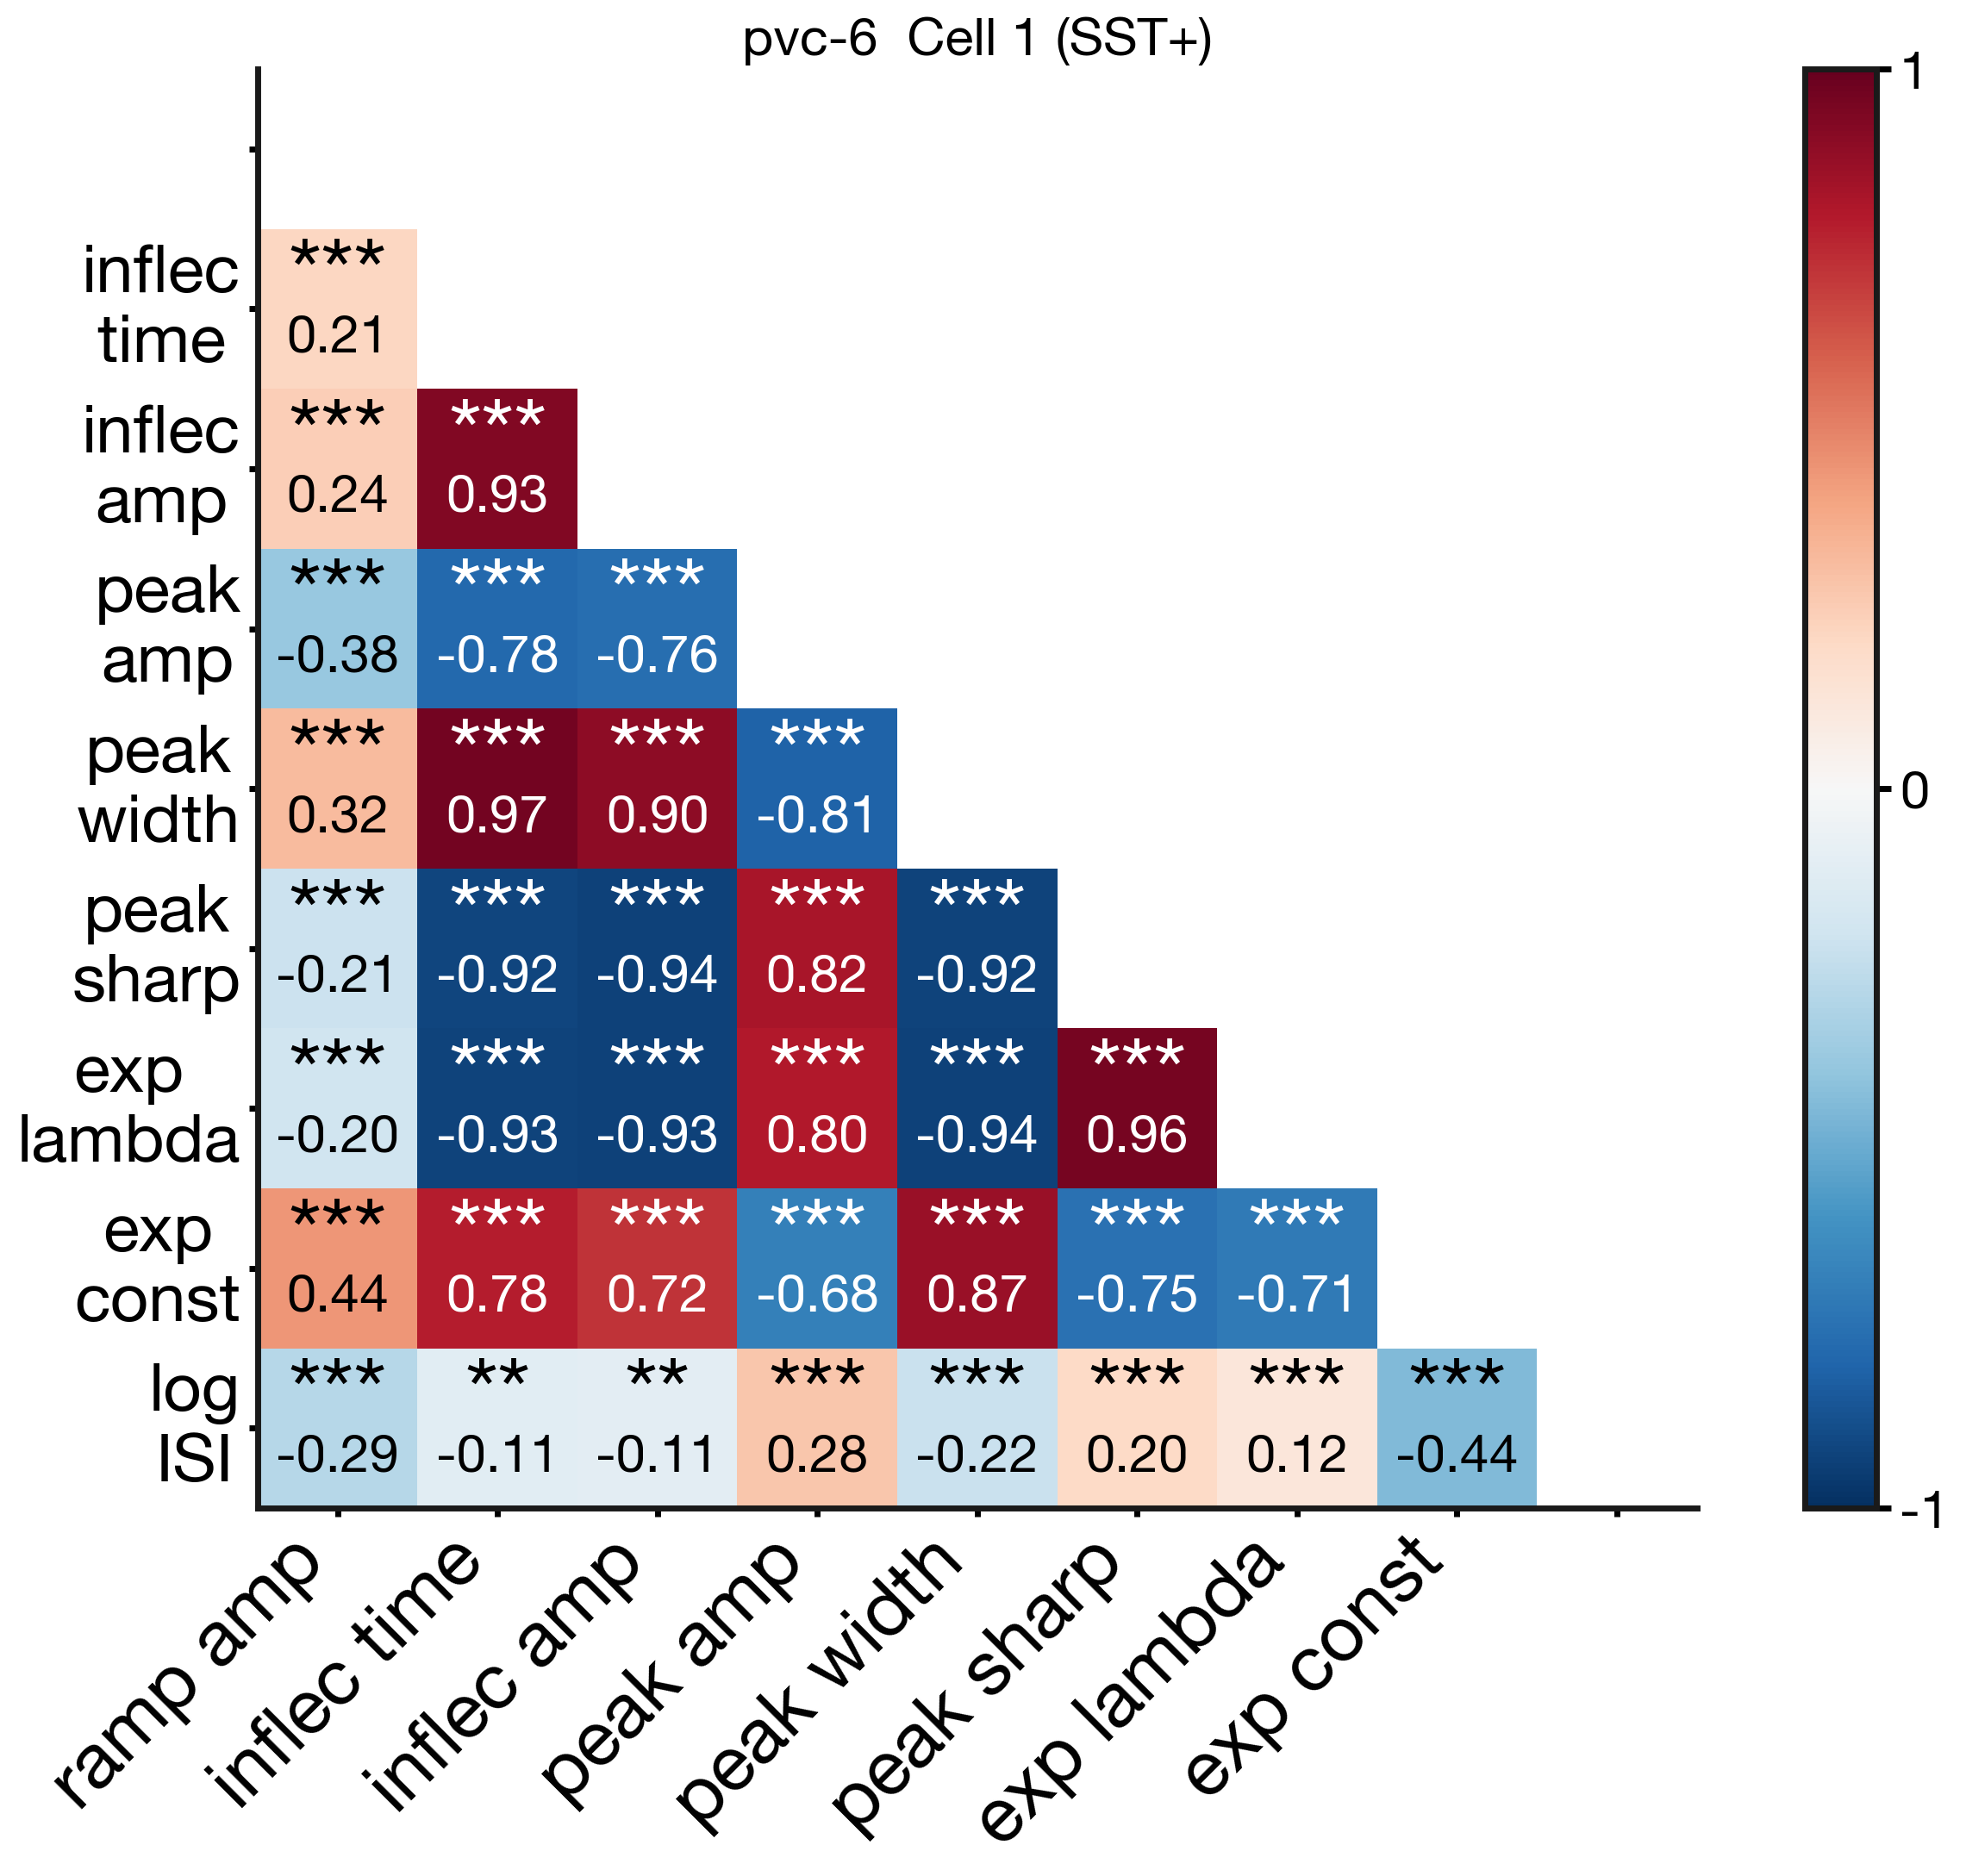

In [4]:
plot_corr_heatmap_only_spk(
    df_pvc6_c1,
    SPK_FEATS,
    title='pvc-6  Cell 1 (SST+)'
)

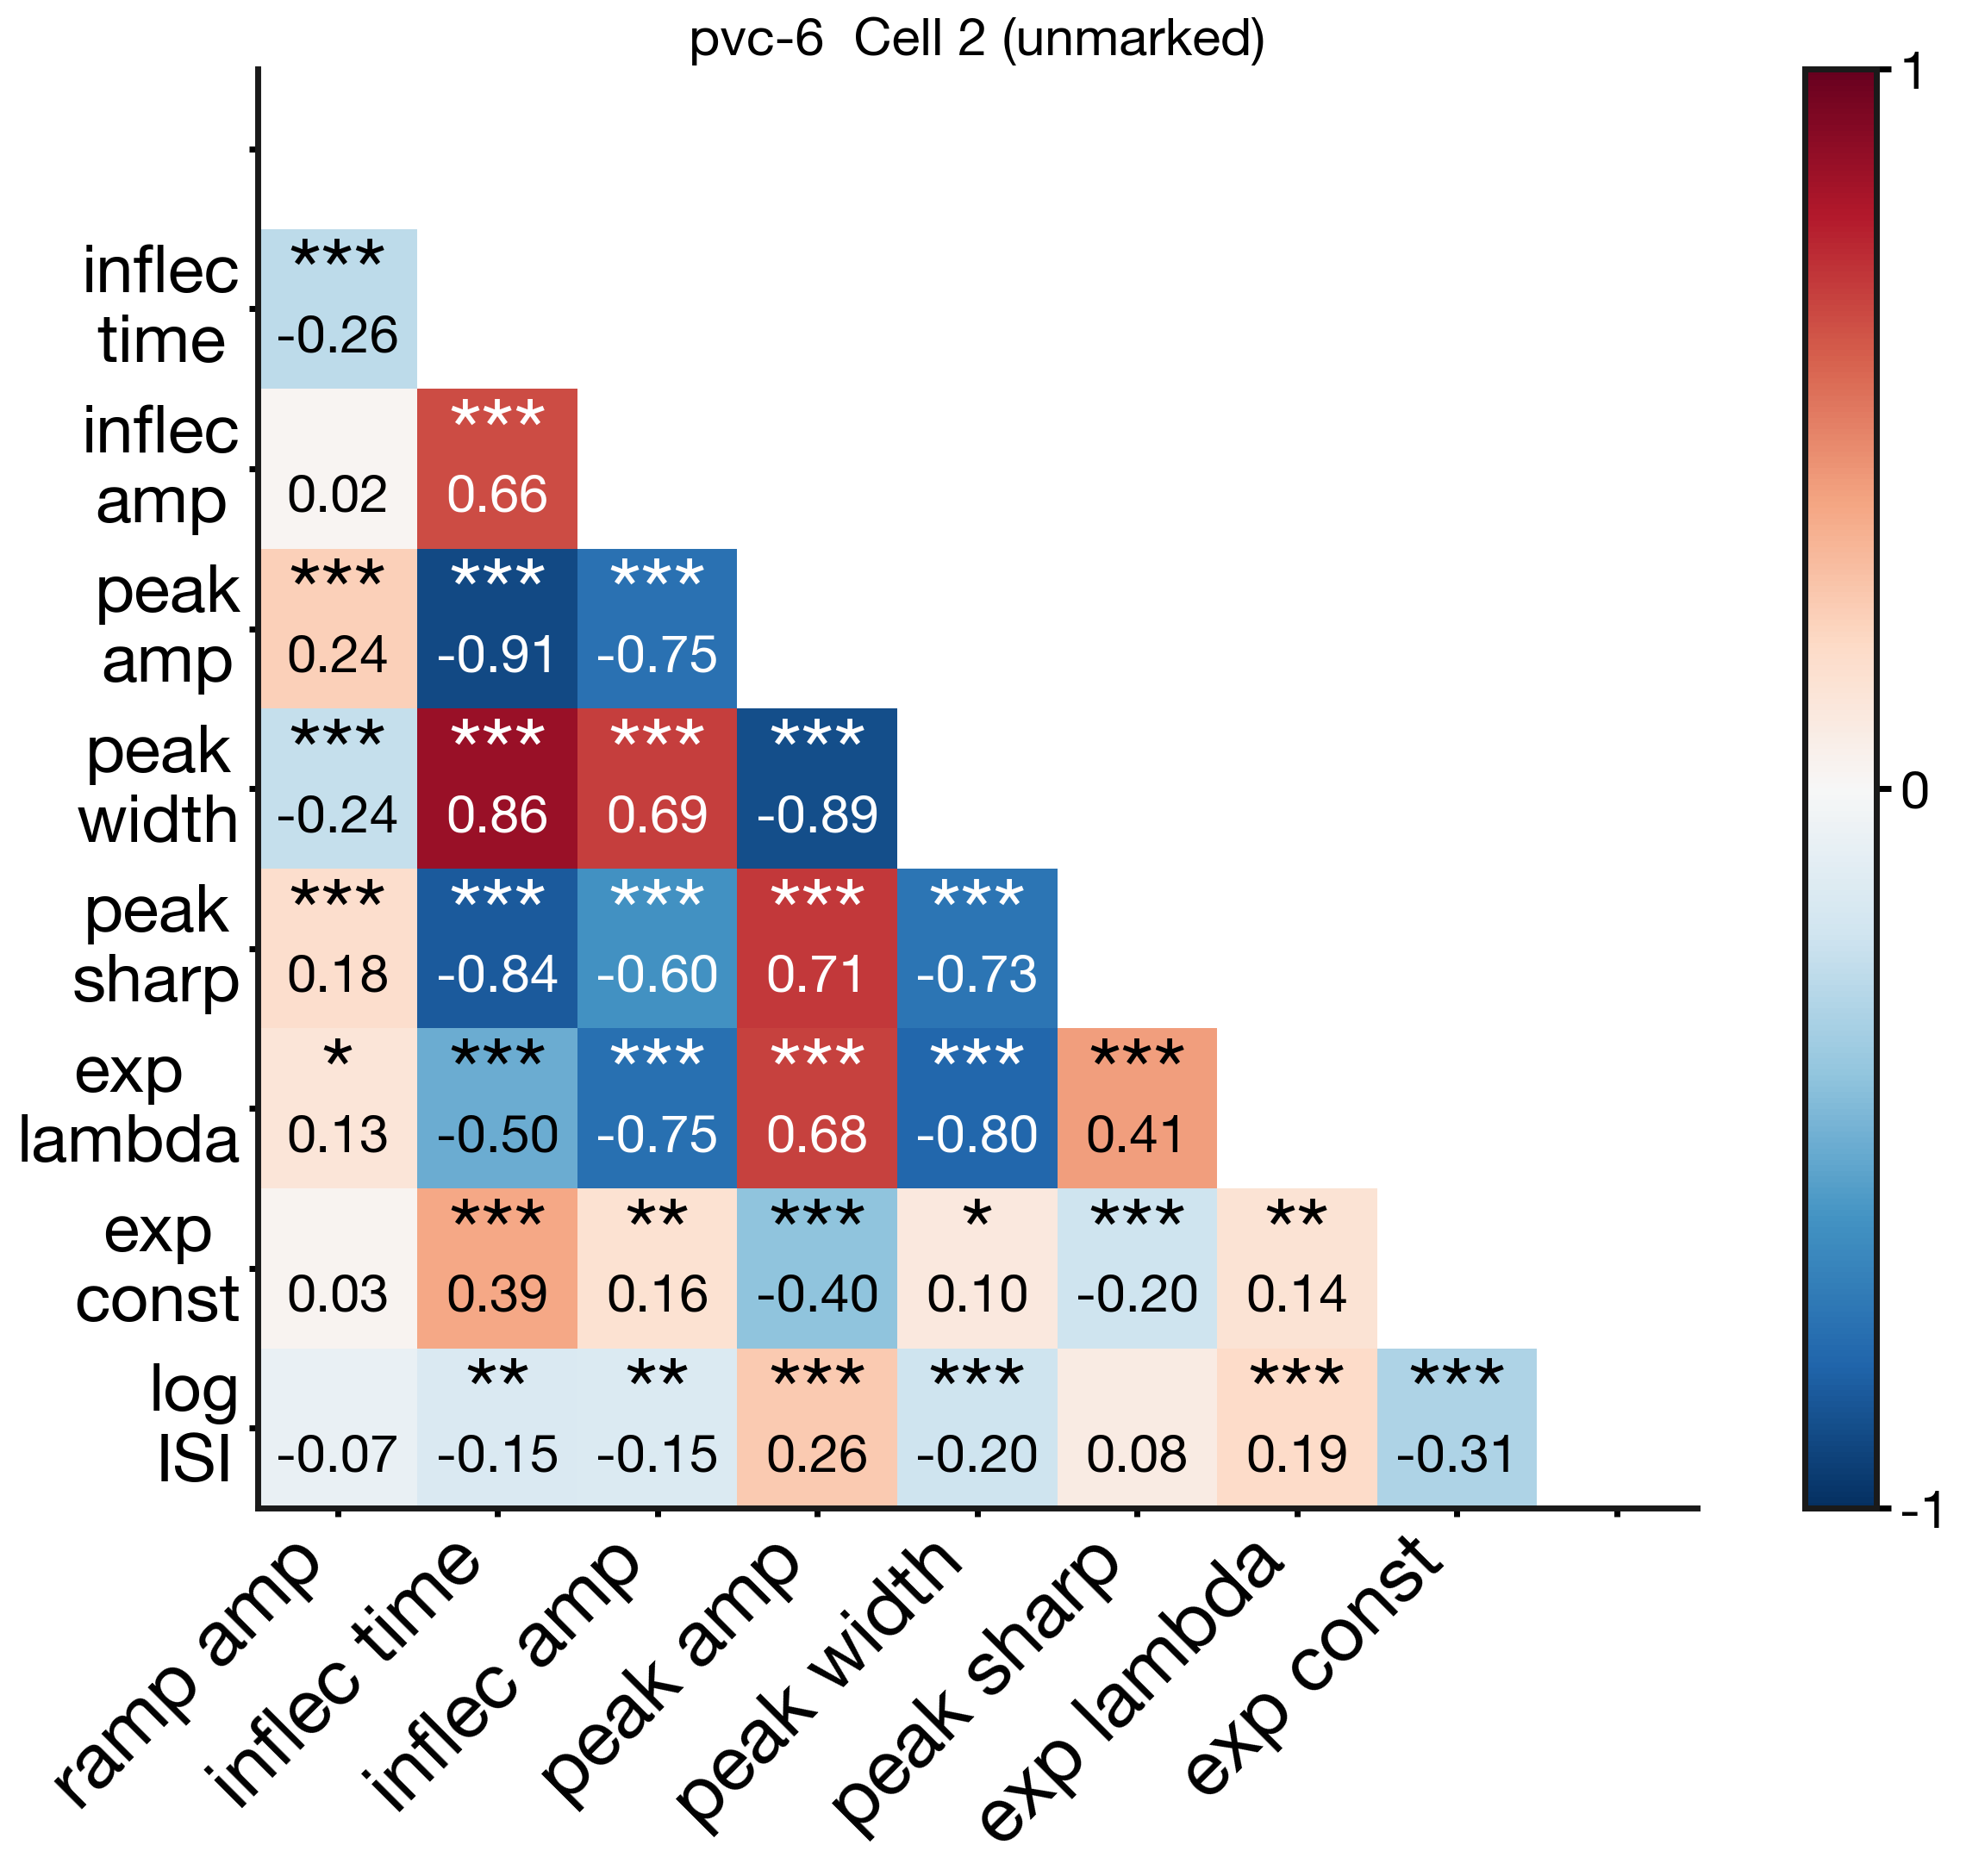

In [5]:
plot_corr_heatmap_only_spk(
    df_pvc6_c2,
    SPK_FEATS,
    title='pvc-6  Cell 2 (unmarked)'
)

## 2. spe-1 — putative IN  
Average within-cell Pearson r across IN cells. Stars = one-sample t-test vs 0, FDR corrected.

/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarnin

IN cells used: 6


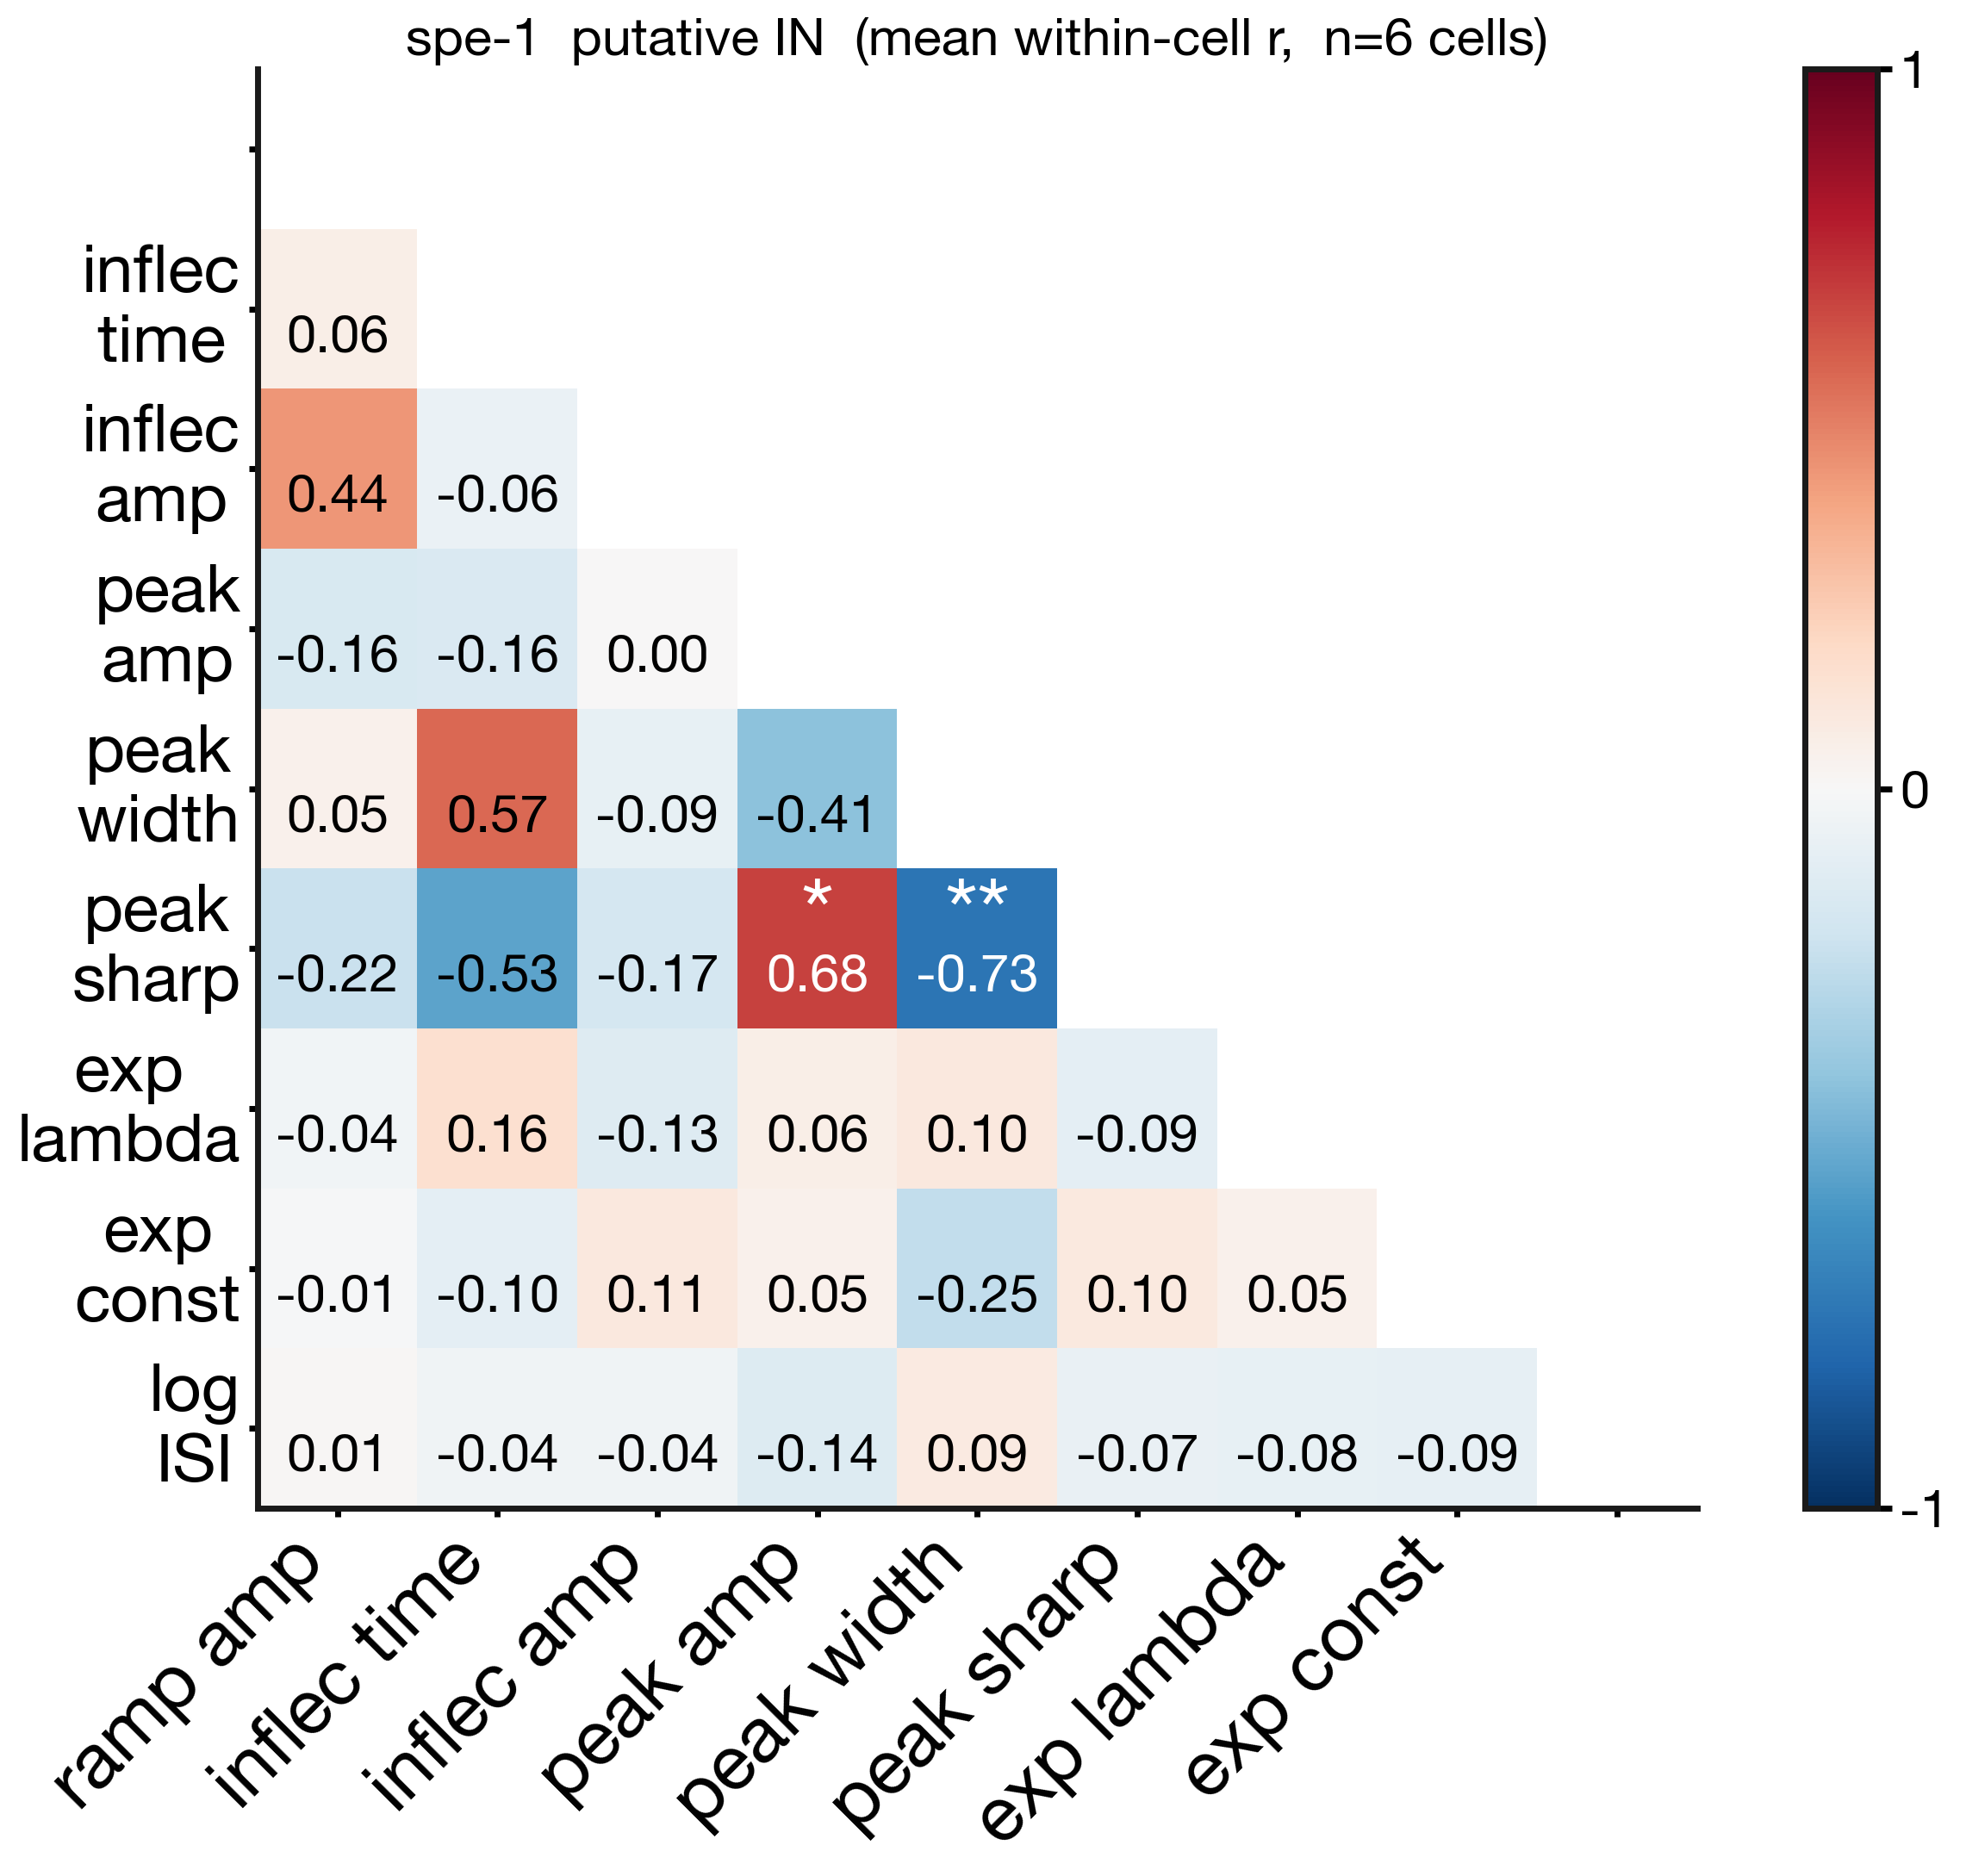

In [6]:
mean_r_in, pval_in, n_in = compute_within_cell_avg_corr(dfs_in, SPK_FEATS)
print(f'IN cells used: {n_in}')
plot_avg_corr_heatmap(
    mean_r_in, pval_in, SPK_FEATS,
    title=f'spe-1  putative IN  (mean within-cell r,  n={n_in} cells)'
)

## 3. spe-1 — putative PC  
Average within-cell Pearson r across PC cells.

PC cells used: 37


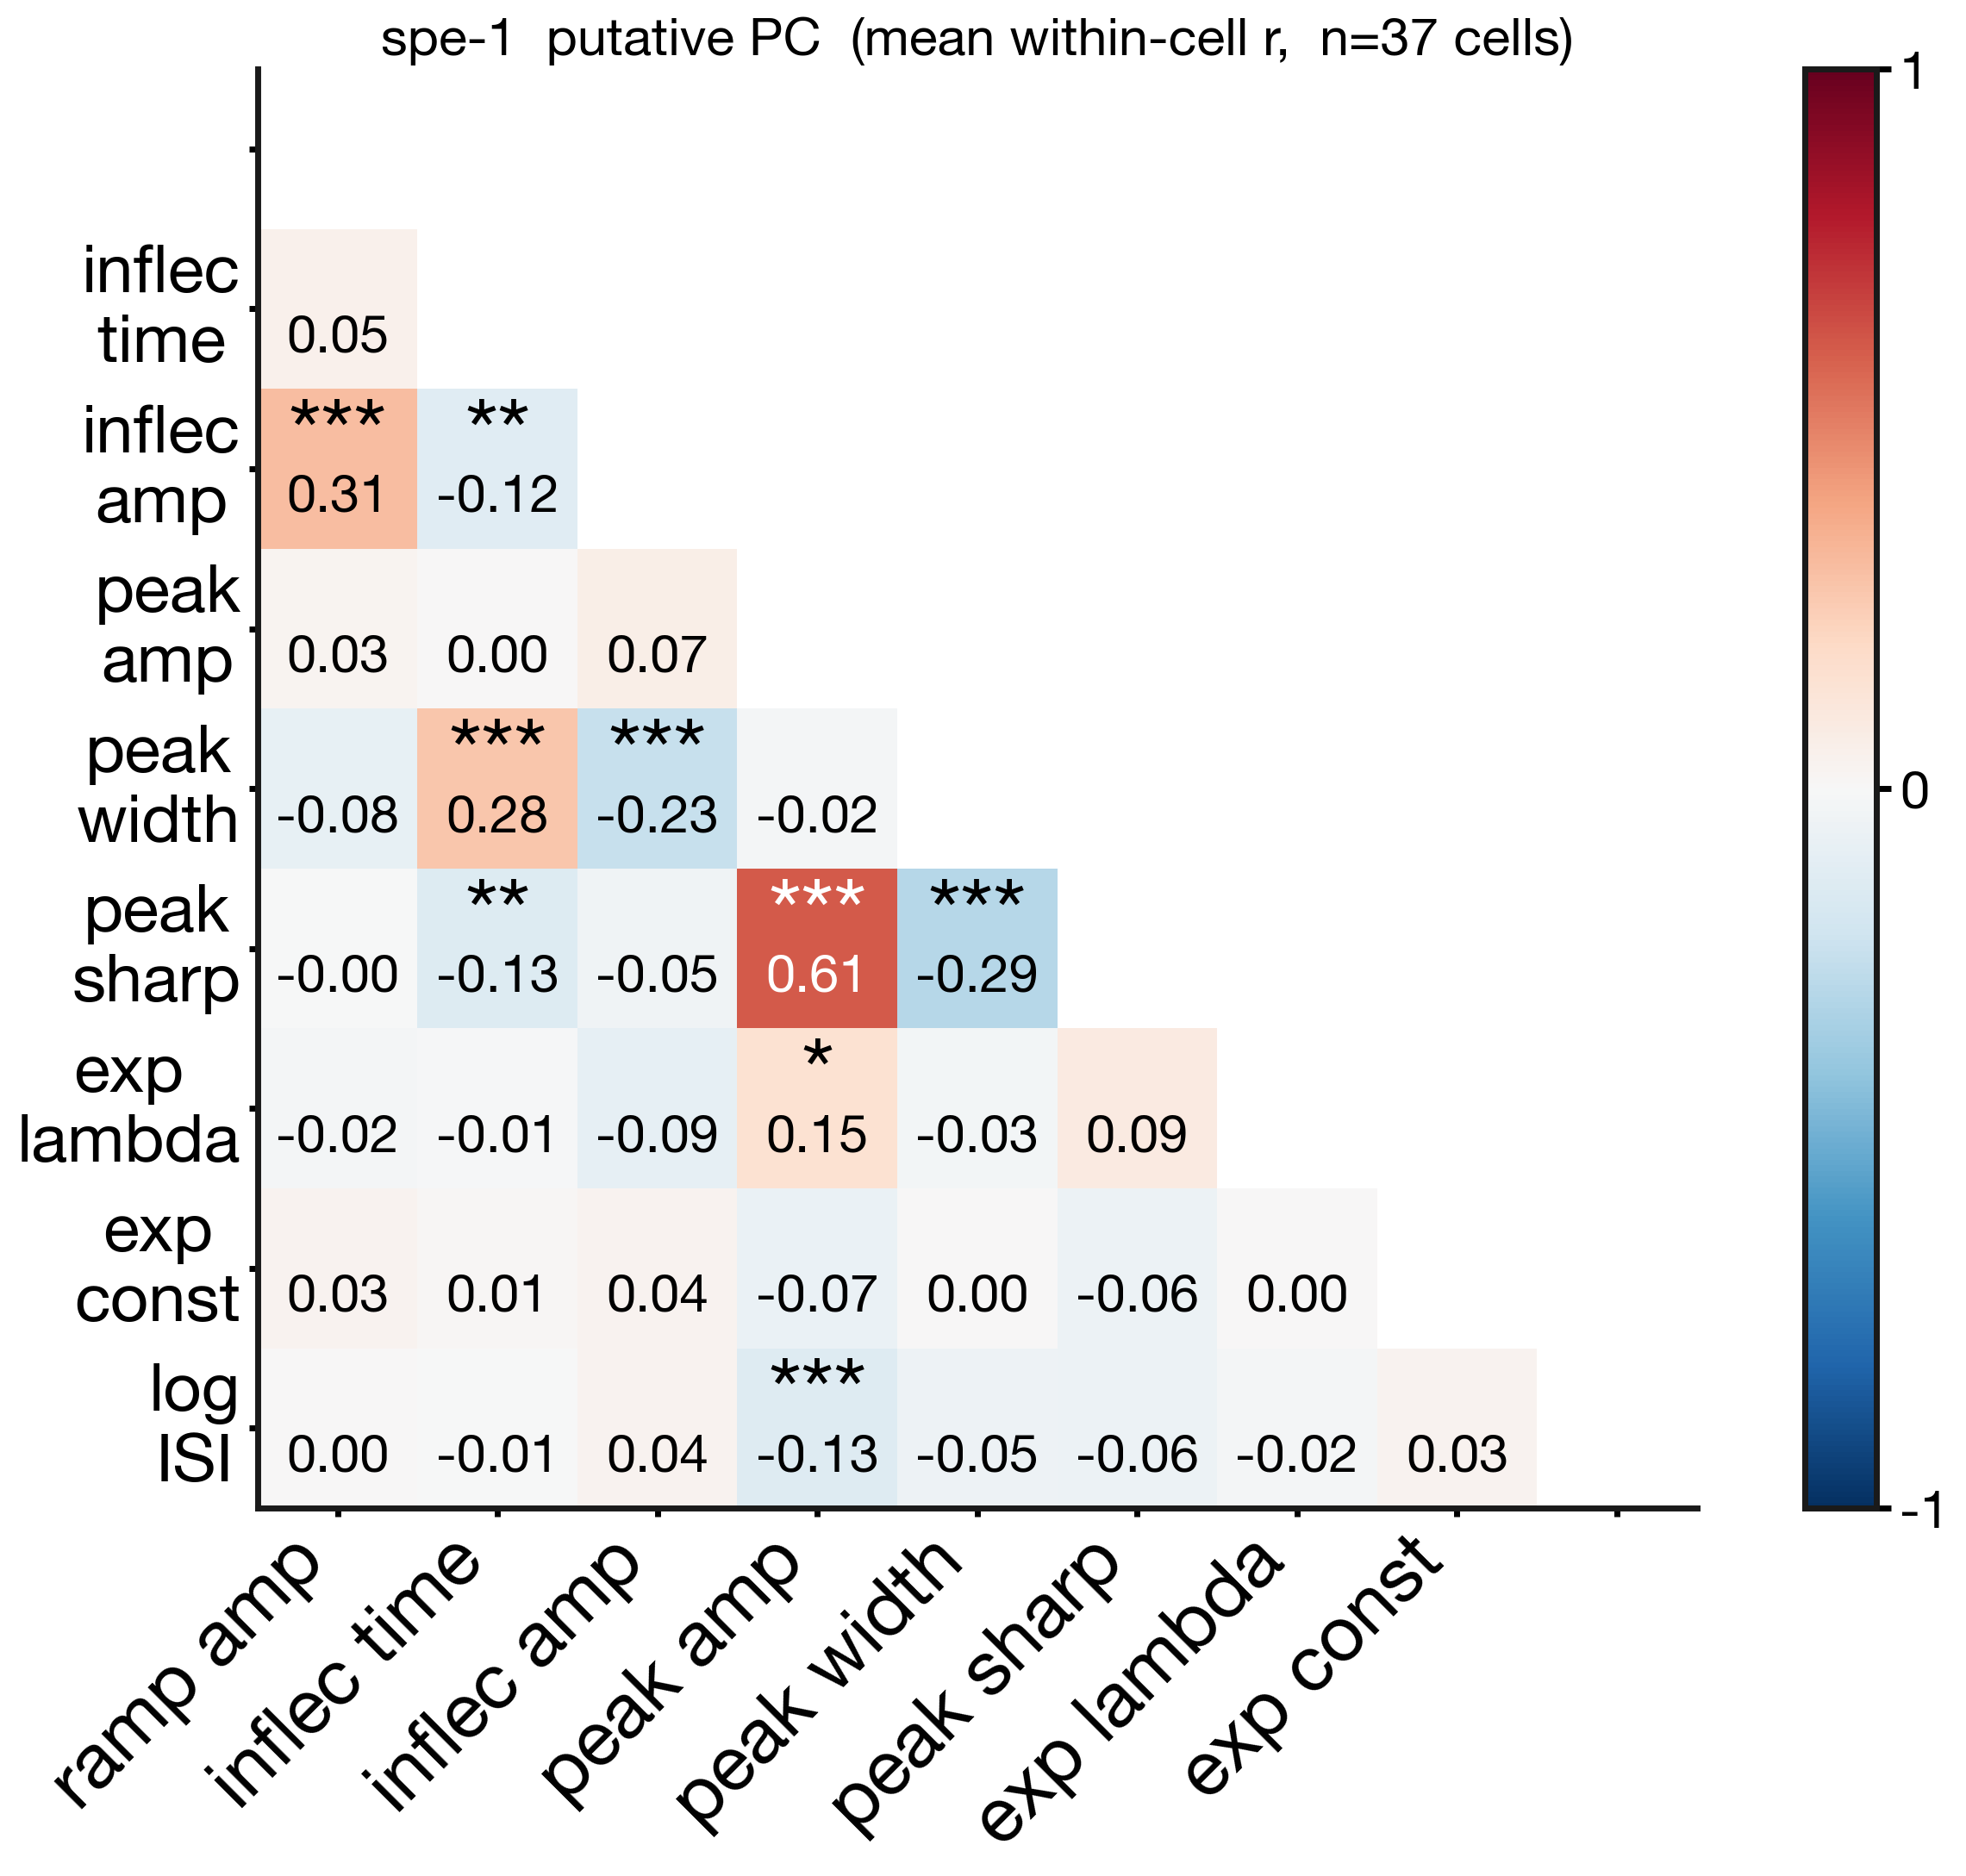

In [7]:
mean_r_pc, pval_pc, n_pc = compute_within_cell_avg_corr(dfs_pc, SPK_FEATS)
print(f'PC cells used: {n_pc}')
plot_avg_corr_heatmap(
    mean_r_pc, pval_pc, SPK_FEATS,
    title=f'spe-1  putative PC  (mean within-cell r,  n={n_pc} cells)'
)

## 4. spe-1 — all cells  
Average within-cell Pearson r across all spe-1 cells.

/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarnin

spe-1 cells used: 43


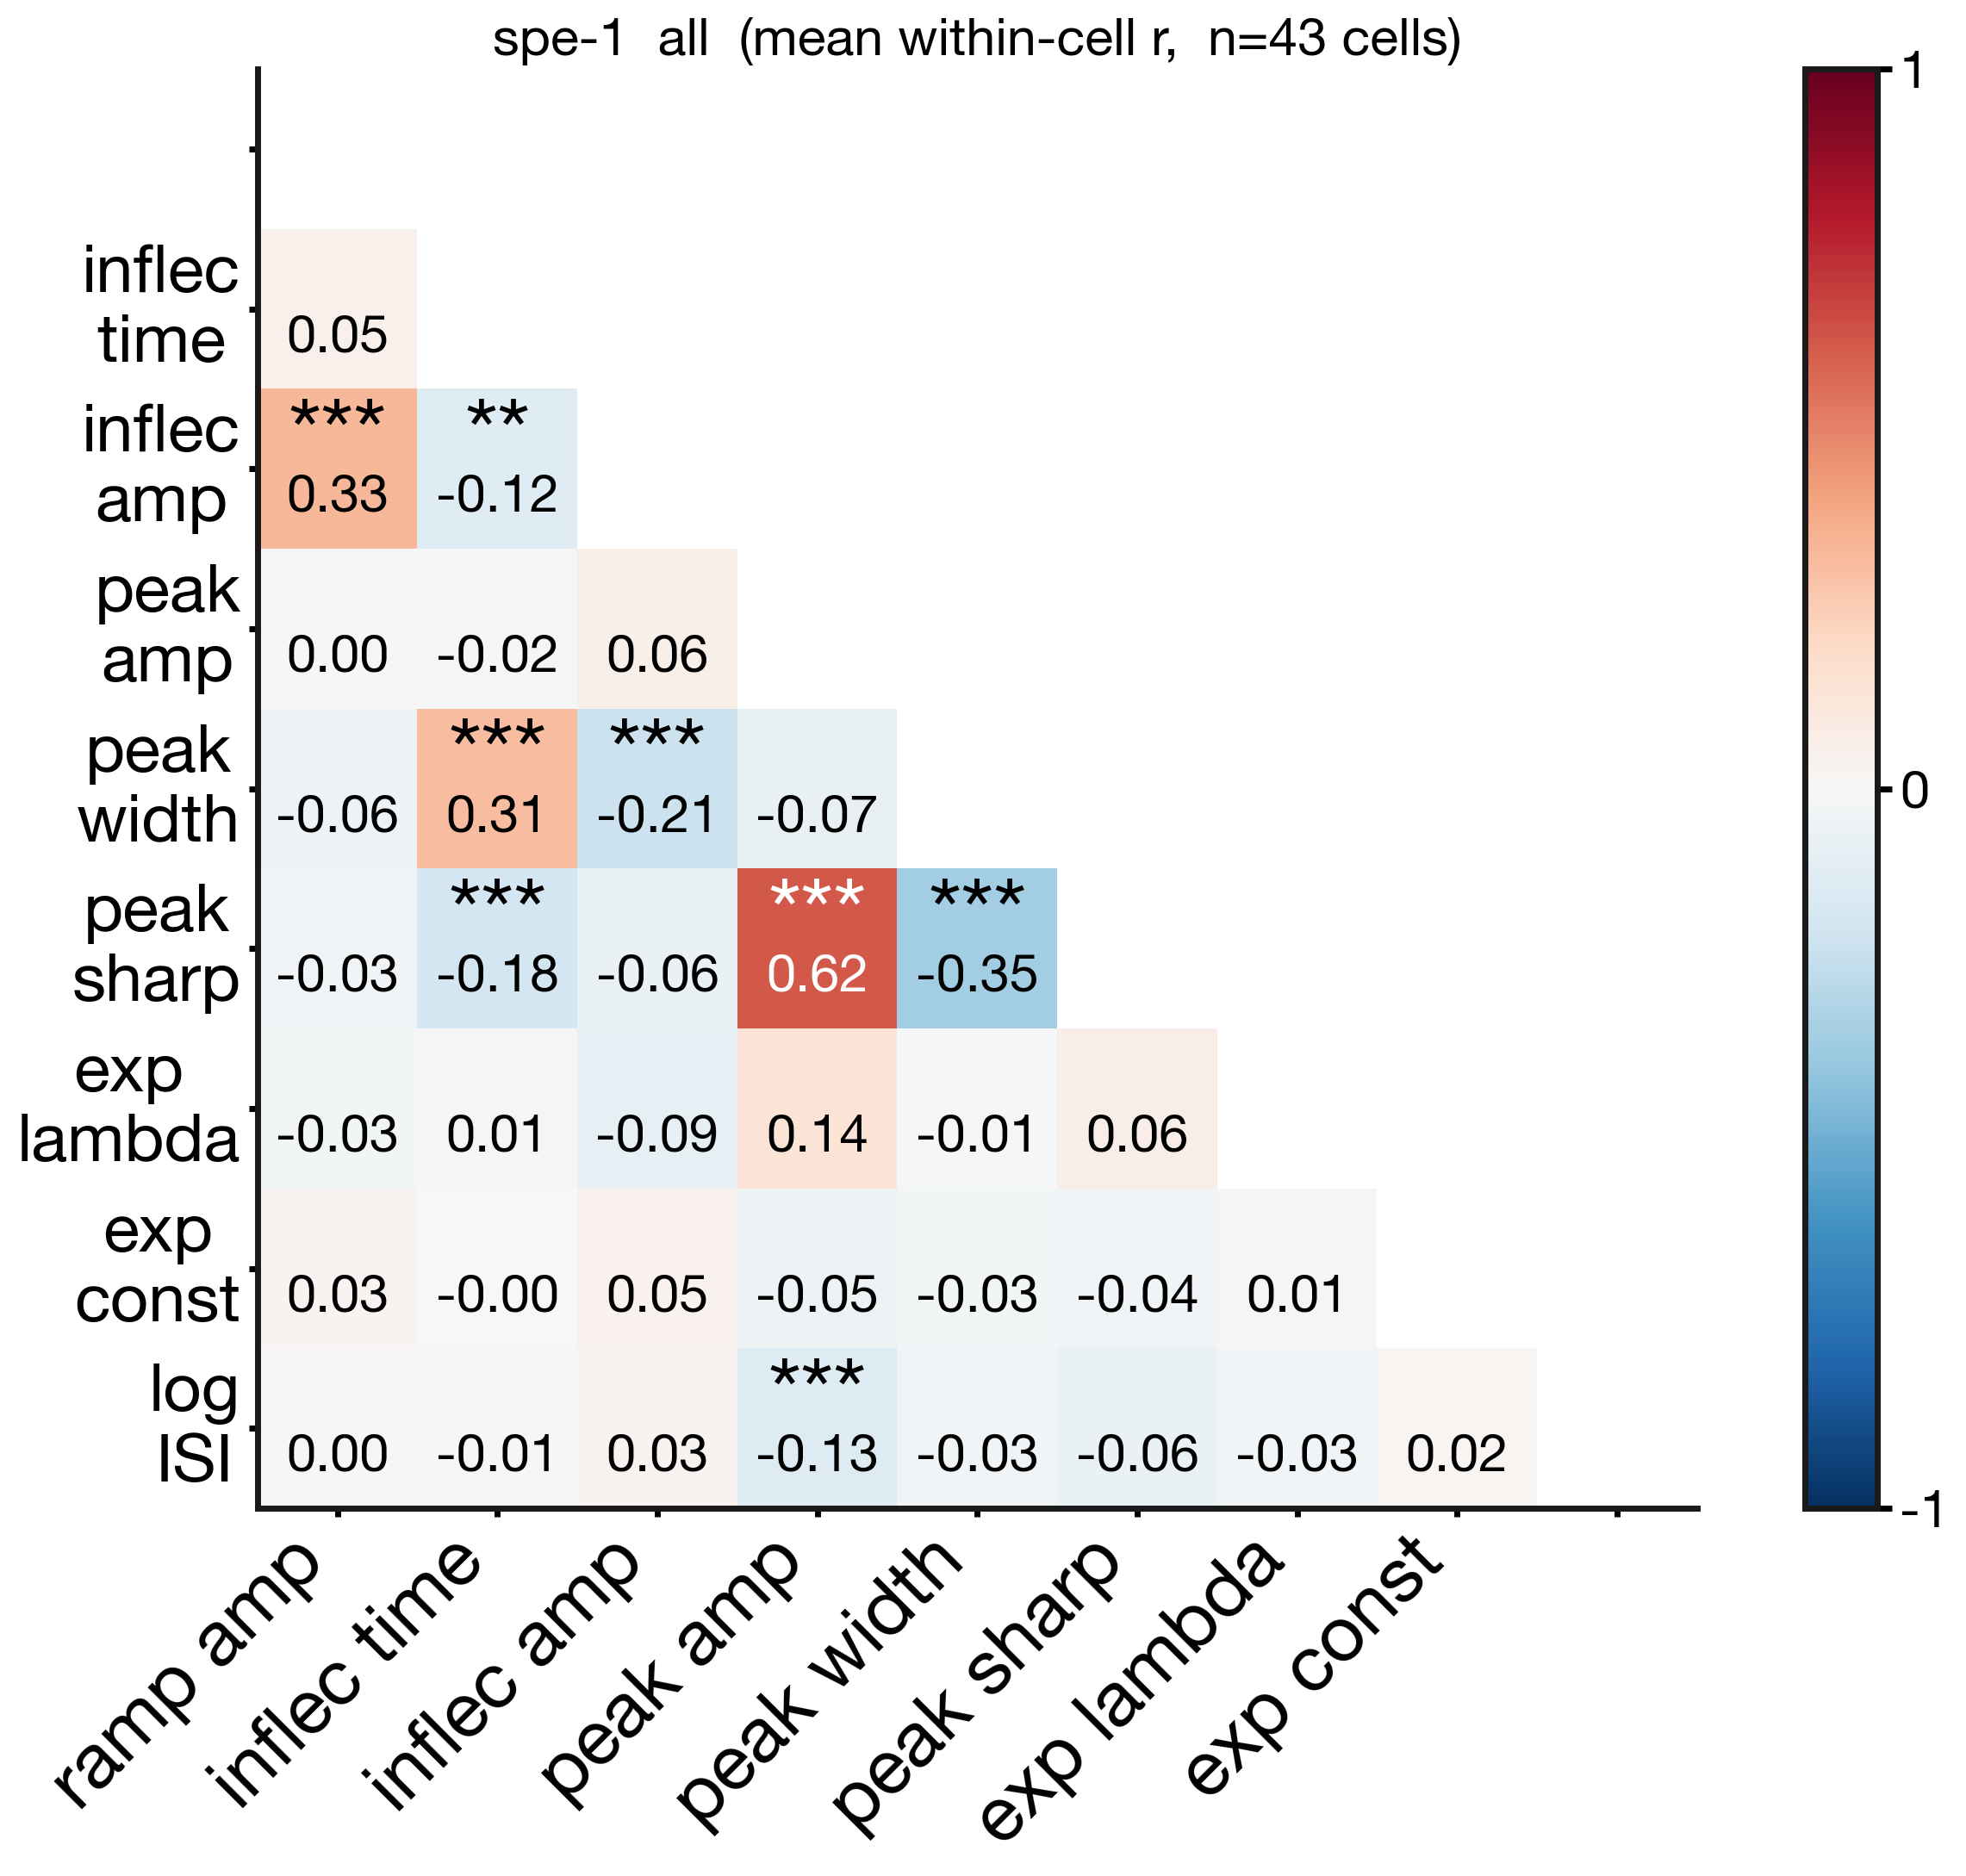

In [8]:
mean_r_spe1, pval_spe1, n_spe1 = compute_within_cell_avg_corr(dfs_all, SPK_FEATS)
print(f'spe-1 cells used: {n_spe1}')
plot_avg_corr_heatmap(
    mean_r_spe1, pval_spe1, SPK_FEATS,
    title=f'spe-1  all  (mean within-cell r,  n={n_spe1} cells)'
)

## 5. All data (spe-1 + pvc-6)  
Average within-cell Pearson r across all spe-1 cells + pvc-6 cells 1 and 2.

/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/blancamartin/opt/anaconda3/envs/spikewise/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarnin

total cells used: 45


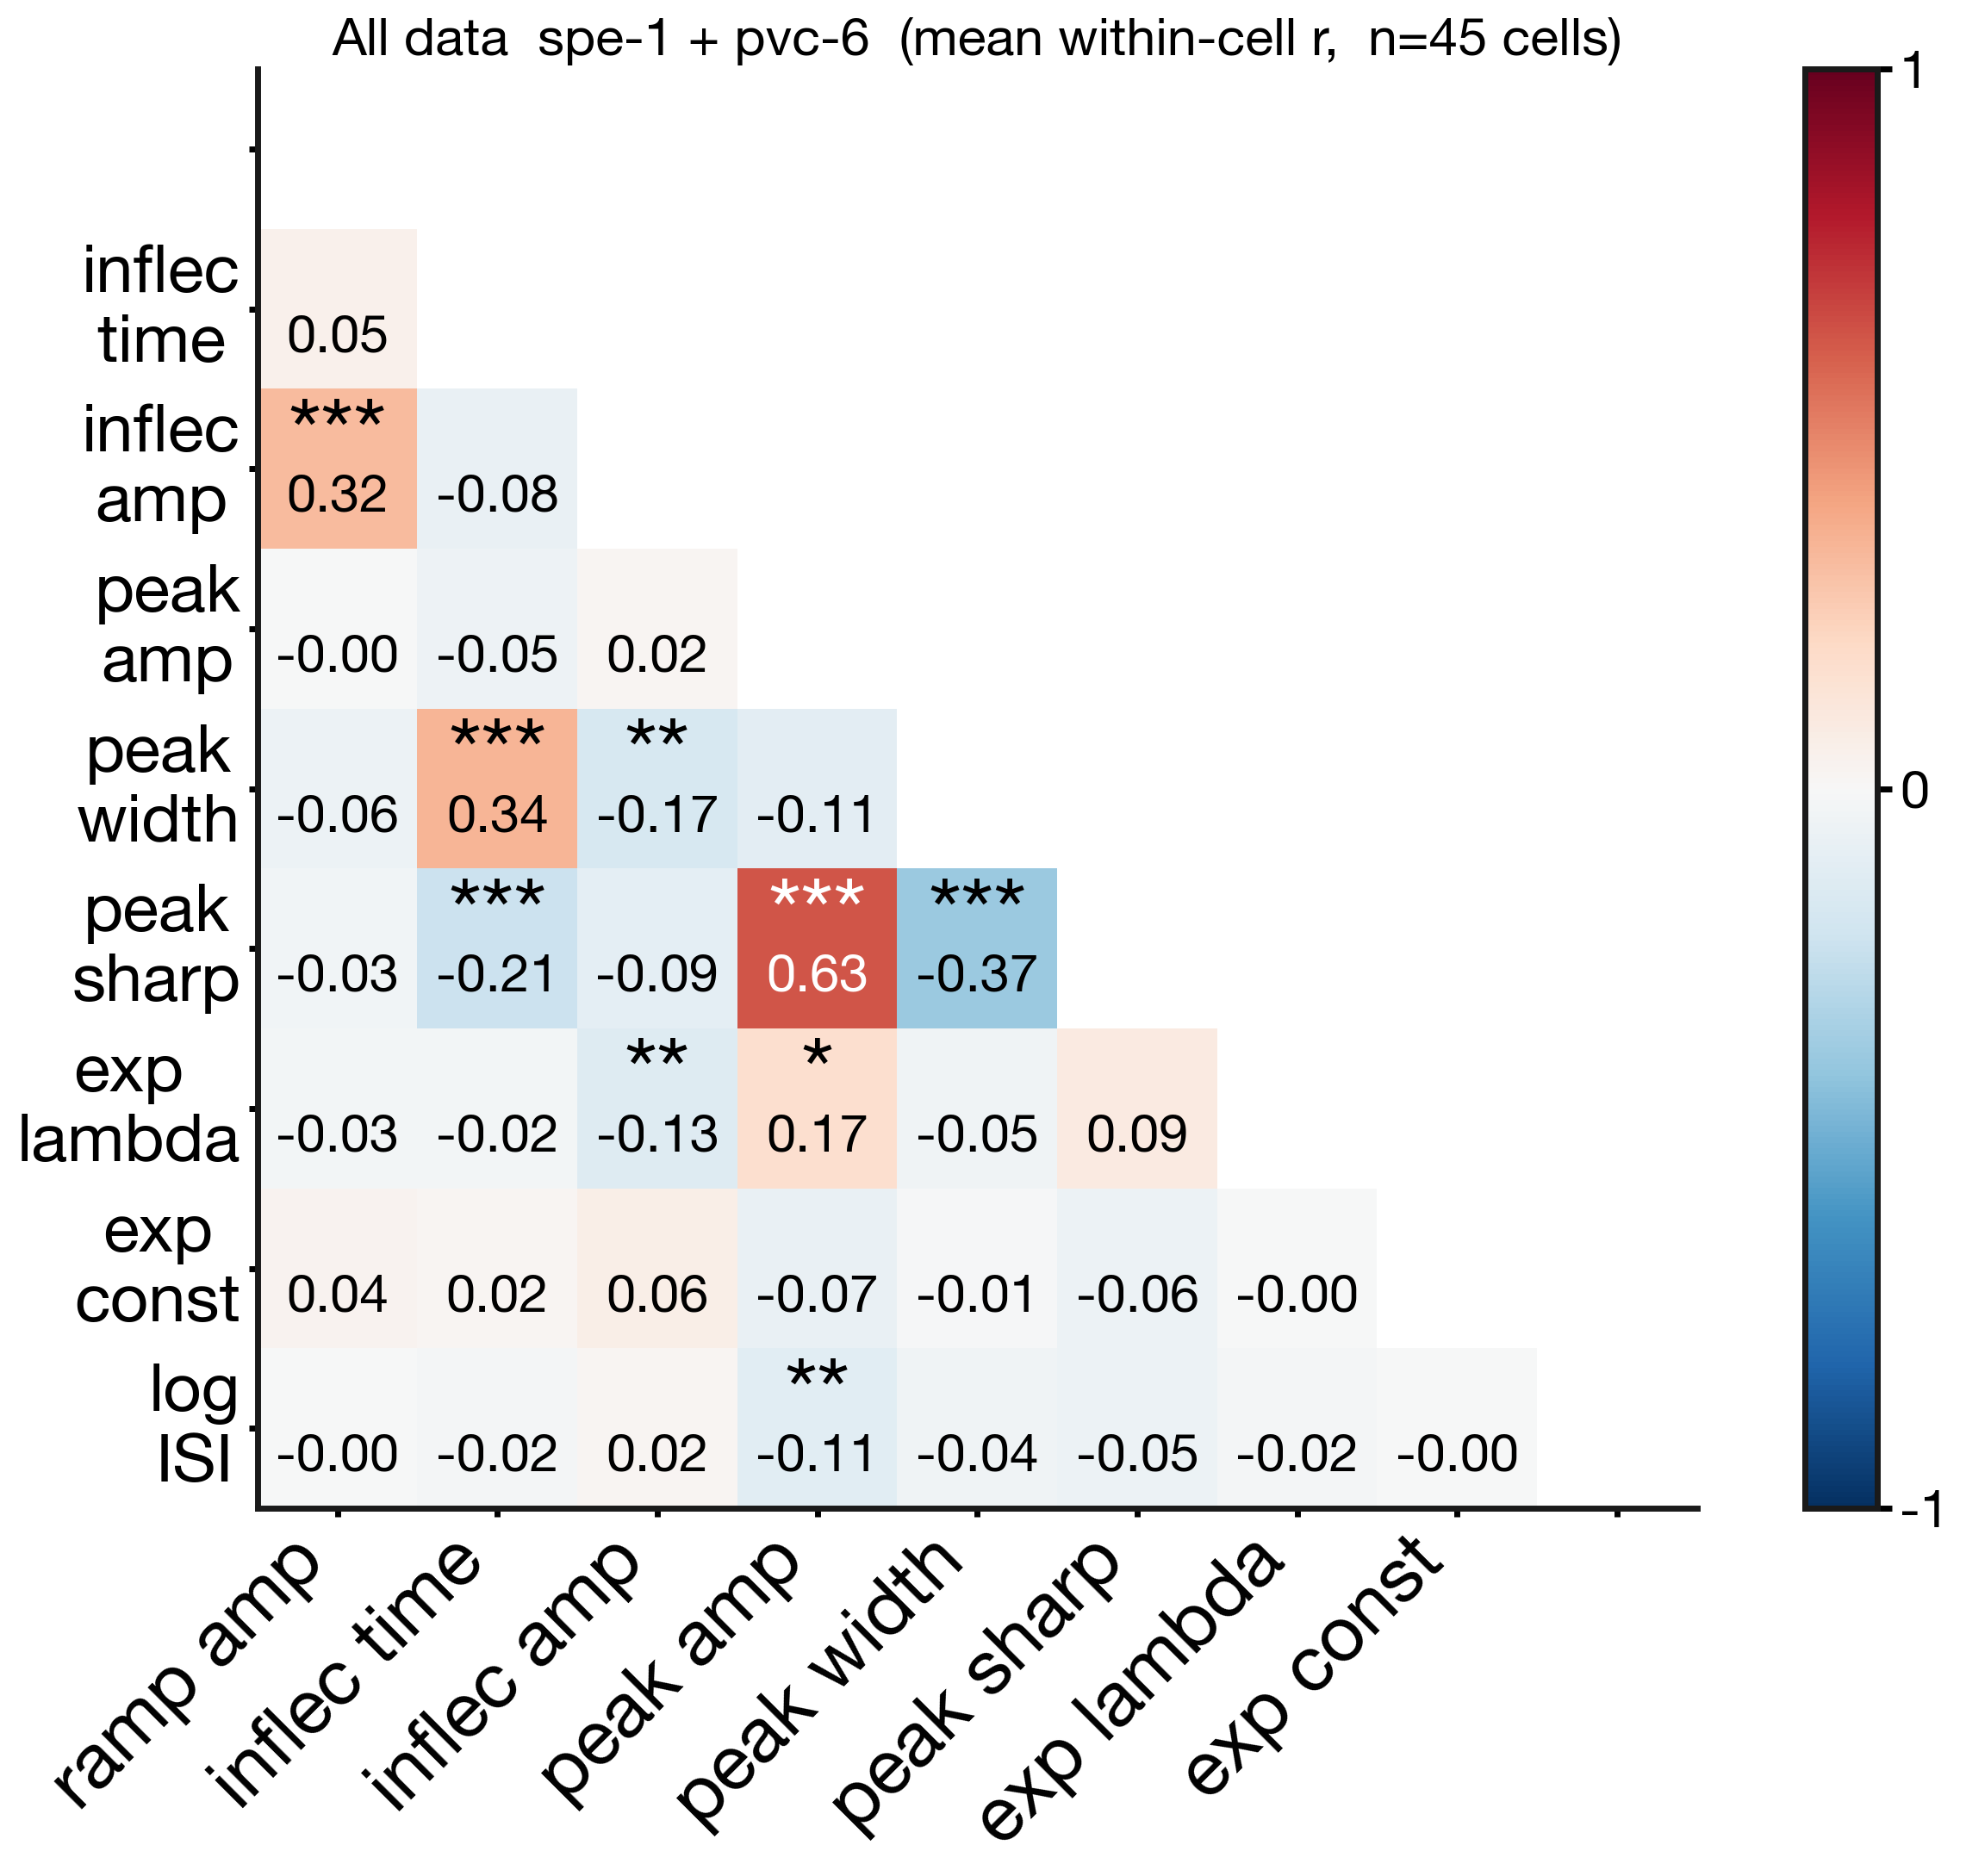

In [9]:
dfs_all_datasets = dfs_all + [df_pvc6_c1, df_pvc6_c2]
mean_r_all, pval_all, n_all = compute_within_cell_avg_corr(dfs_all_datasets, SPK_FEATS)
print(f'total cells used: {n_all}')
plot_avg_corr_heatmap(
    mean_r_all, pval_all, SPK_FEATS,
    title=f'All data  spe-1 + pvc-6  (mean within-cell r,  n={n_all} cells)'
)

## 6. Representative spe-1 cells — IN and PC with most spikes

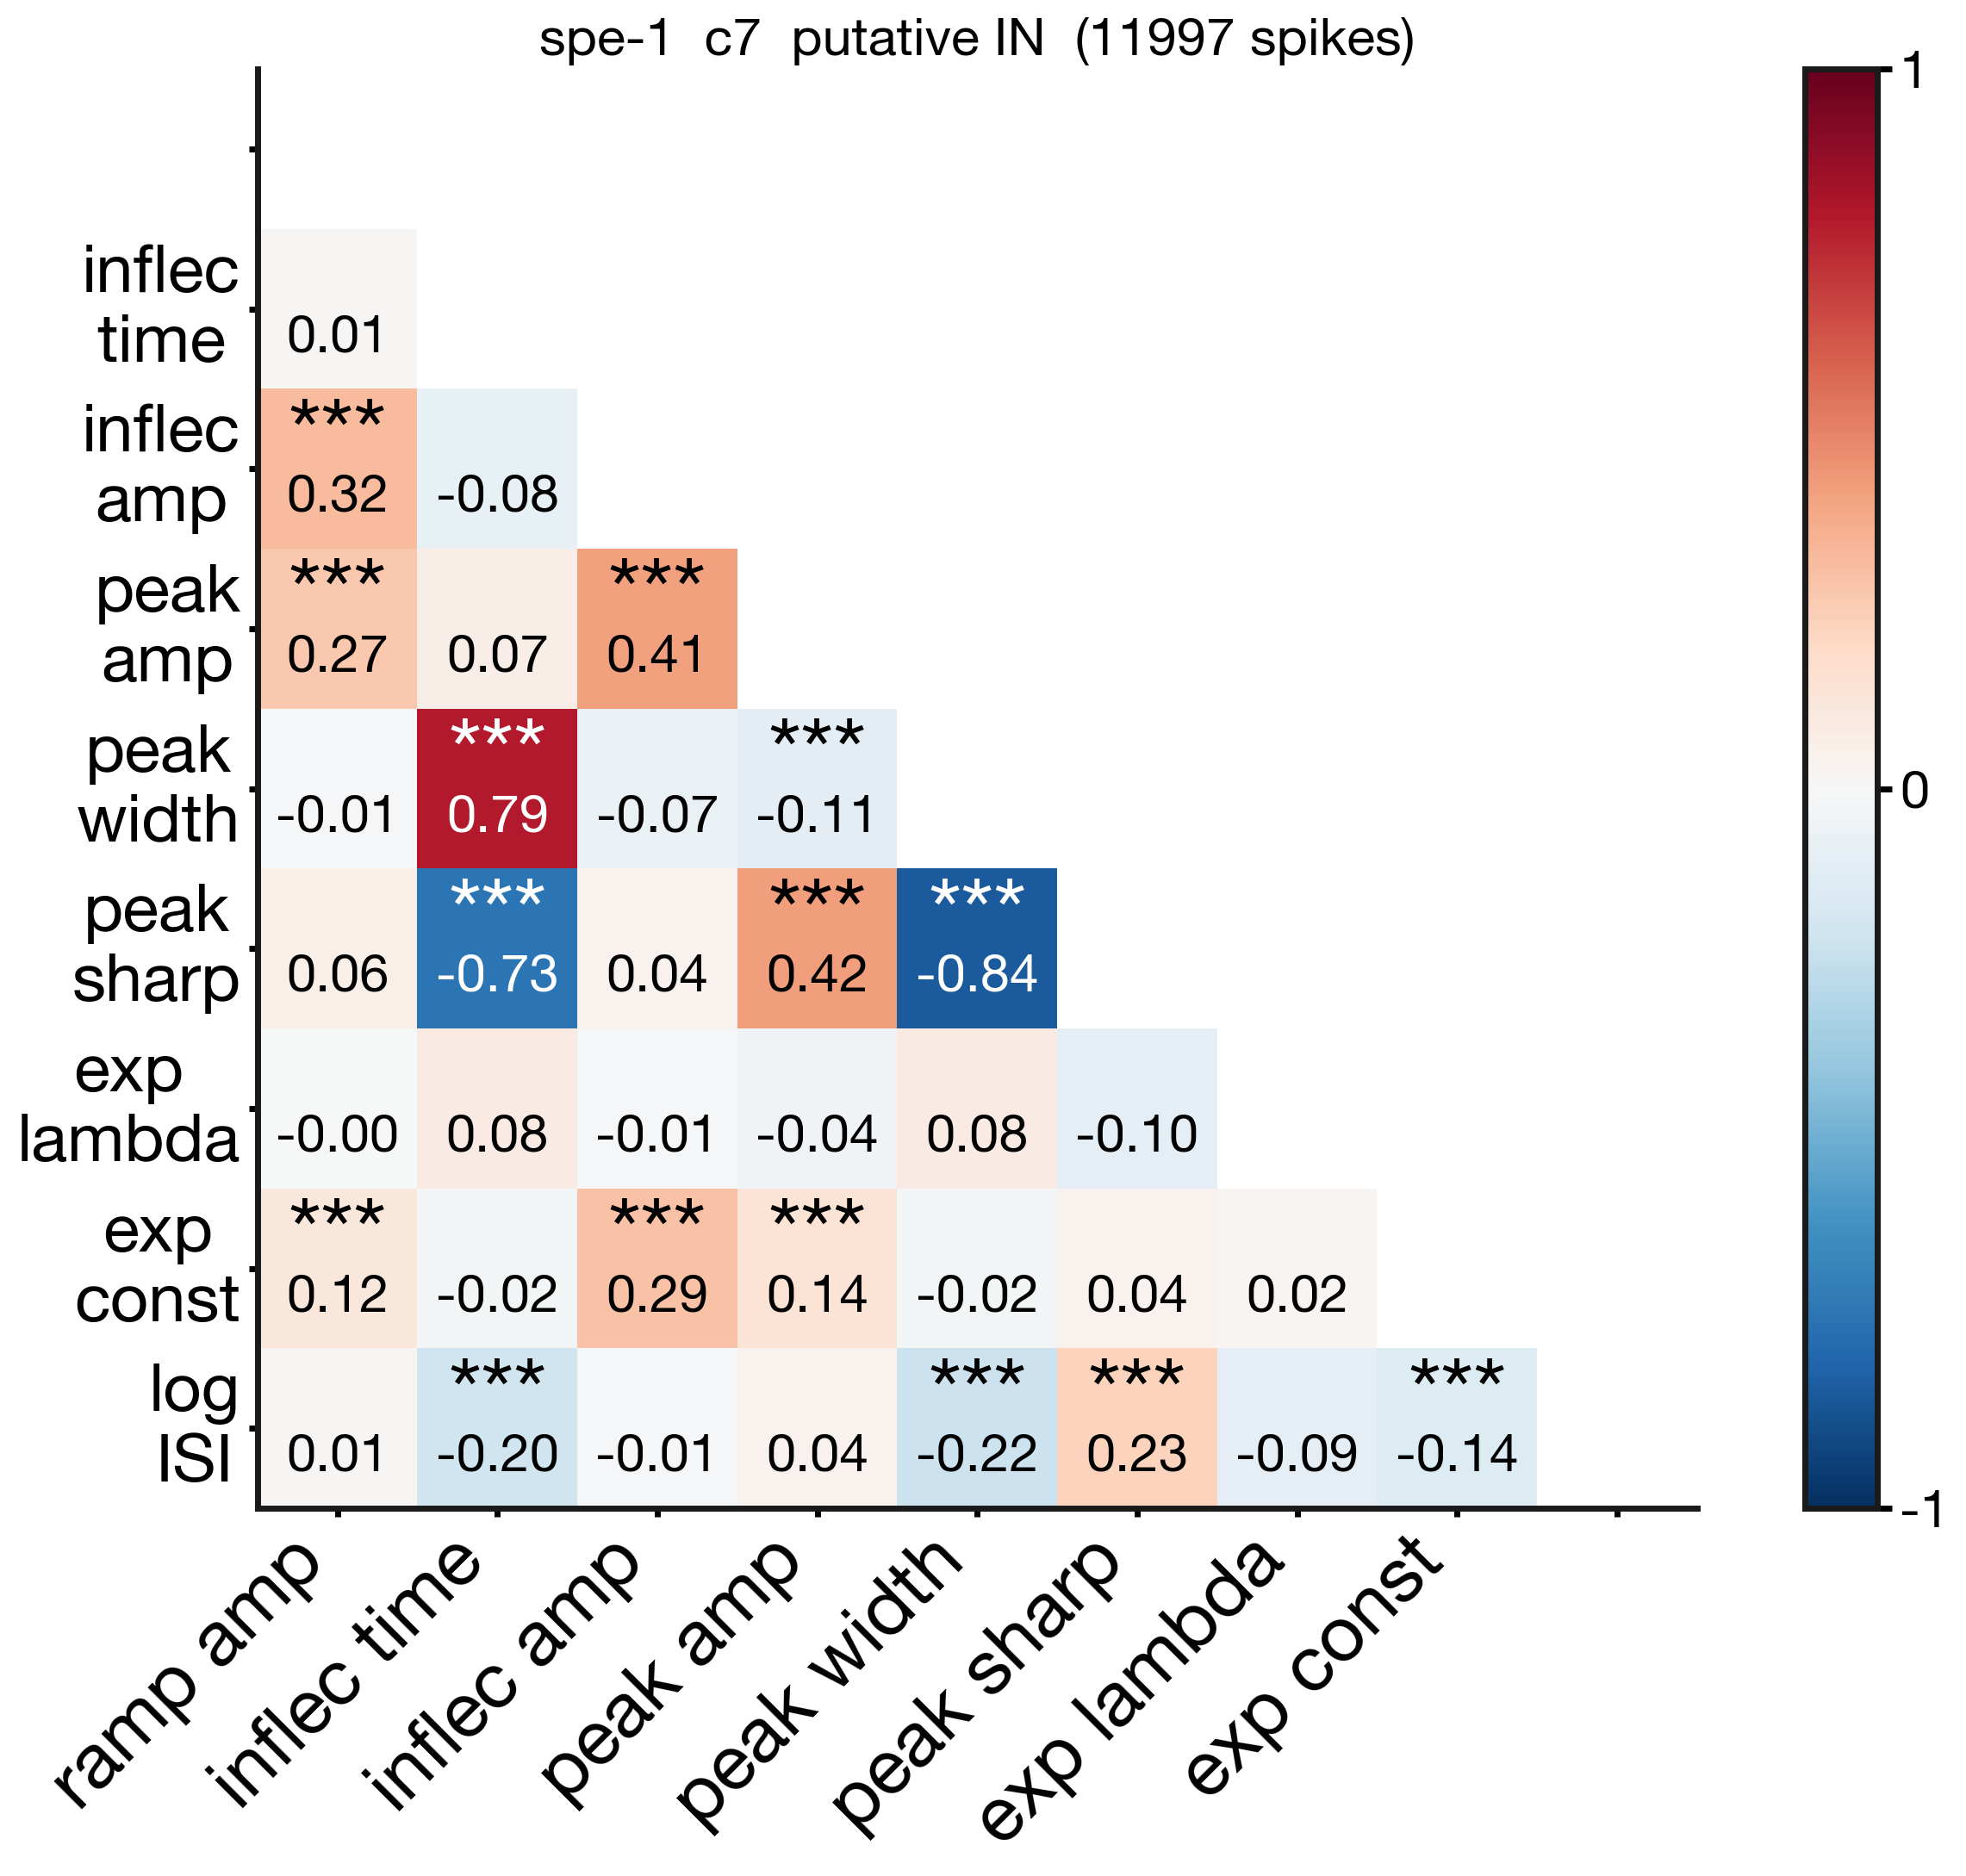

In [10]:
plot_corr_heatmap_only_spk(
    best_in_df,
    SPK_FEATS,
    title=f'spe-1  {best_in_cid}  putative IN  ({len(best_in_df)} spikes)'
)

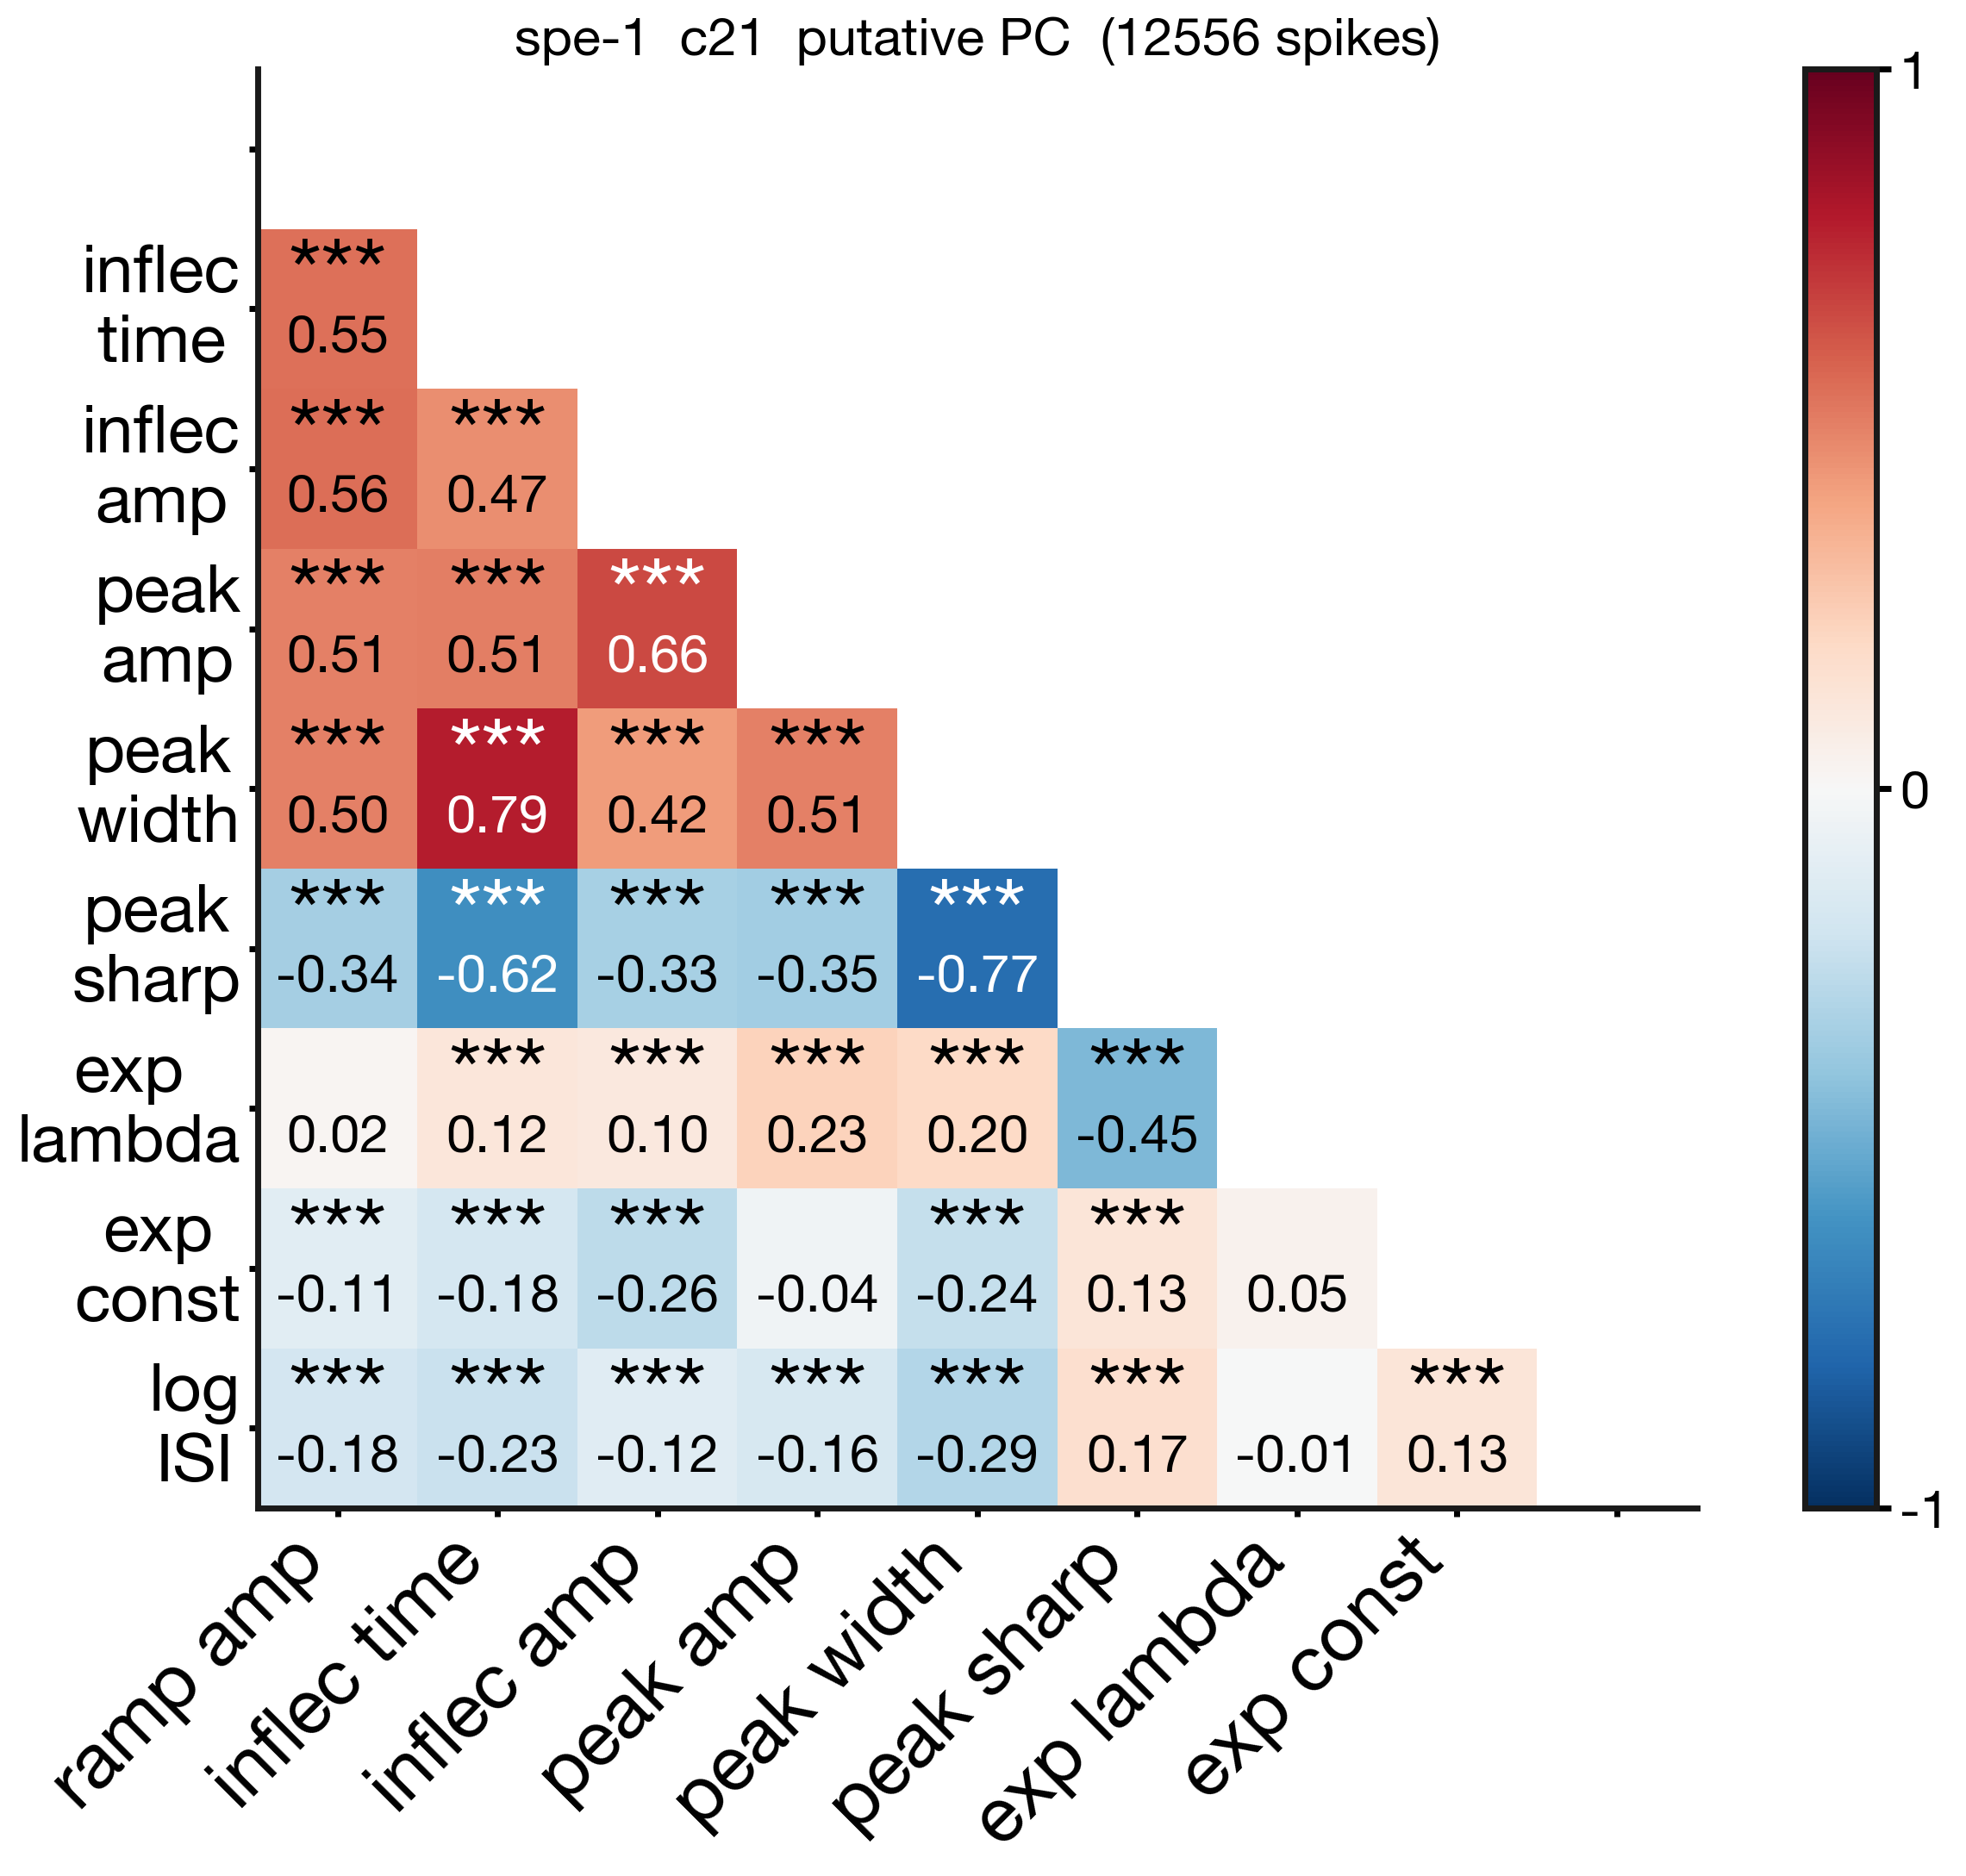

In [11]:
plot_corr_heatmap_only_spk(
    best_pc_df,
    SPK_FEATS,
    title=f'spe-1  {best_pc_cid}  putative PC  ({len(best_pc_df)} spikes)'
)

## 7. Decay correlation direction across spe-1 cells

The population average r(exp_lambda, peak_amp) is near zero (section 4), but not because individual cells lack structure — individual cells show significant correlations in both directions. Below: per-cell r ranked from negative to positive. Orange = r > 0, blue = r < 0; filled = significant (p < 0.05), open = not significant.

In [12]:
from spk_feat_cluster_comp_analysis import (
    compute_exp_lambda_corr_per_cell,
    plot_exp_lambda_strip,
    plot_exp_lambda_strip_legend,
    plot_exp_lambda_strip_stats,
    plot_two_corr_heatmaps,
)

df_corr_dir = compute_exp_lambda_corr_per_cell(dfs_all, cids_all)
print(f"n cells: {len(df_corr_dir)}")
print(f"  positive r: {(df_corr_dir['r'] > 0).sum()}")
print(f"  negative r: {(df_corr_dir['r'] < 0).sum()}")
print(f"  significant (p<0.05): {df_corr_dir['significant'].sum()}")

n cells: 43
  positive r: 26
  negative r: 17
  significant (p<0.05): 38


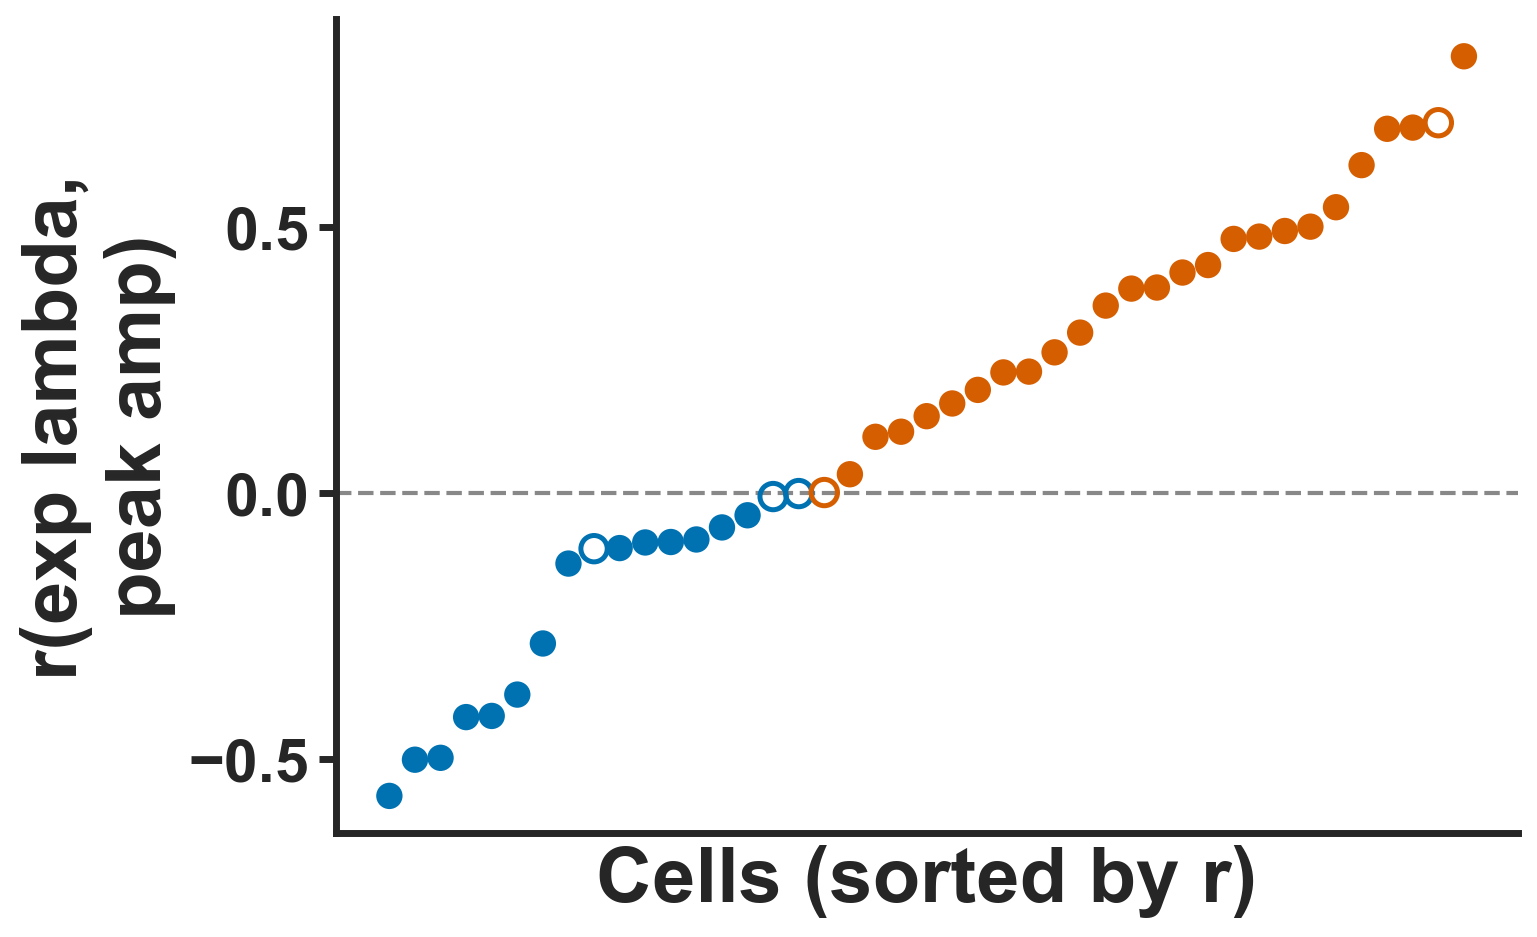

In [13]:
fig_strip, df_strip_sorted, _n_pos, _n_neg, _n_pos_sig, _n_neg_sig = plot_exp_lambda_strip(
    df_corr_dir,
    fs_ax=28, fs_tk=22, lw_sp=2.5, figsize=(8, 5),
)

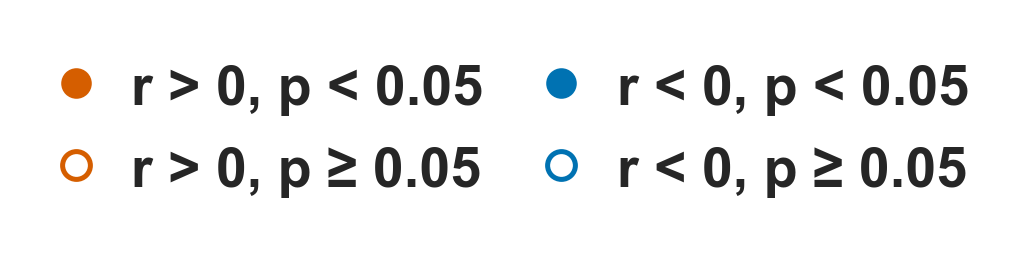

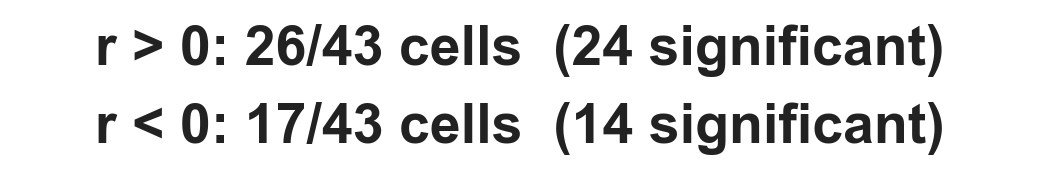

In [14]:
fig_strip_legend = plot_exp_lambda_strip_legend(fs=20, figsize=(4.5, 1.6))
fig_strip_stats  = plot_exp_lambda_strip_stats(_n_pos, _n_neg, _n_pos_sig, _n_neg_sig,
                                                fs=20, figsize=(5.5, 1.2))

### c14 vs pvc-6 c1 — best spe-1 match

c14 shows 7/7 sign matches to pvc-6 c1 for exp_lambda correlations with other features. Heatmaps for pvc-6 c1 (SST+, reference) and spe-1 c14 (best match) side by side.

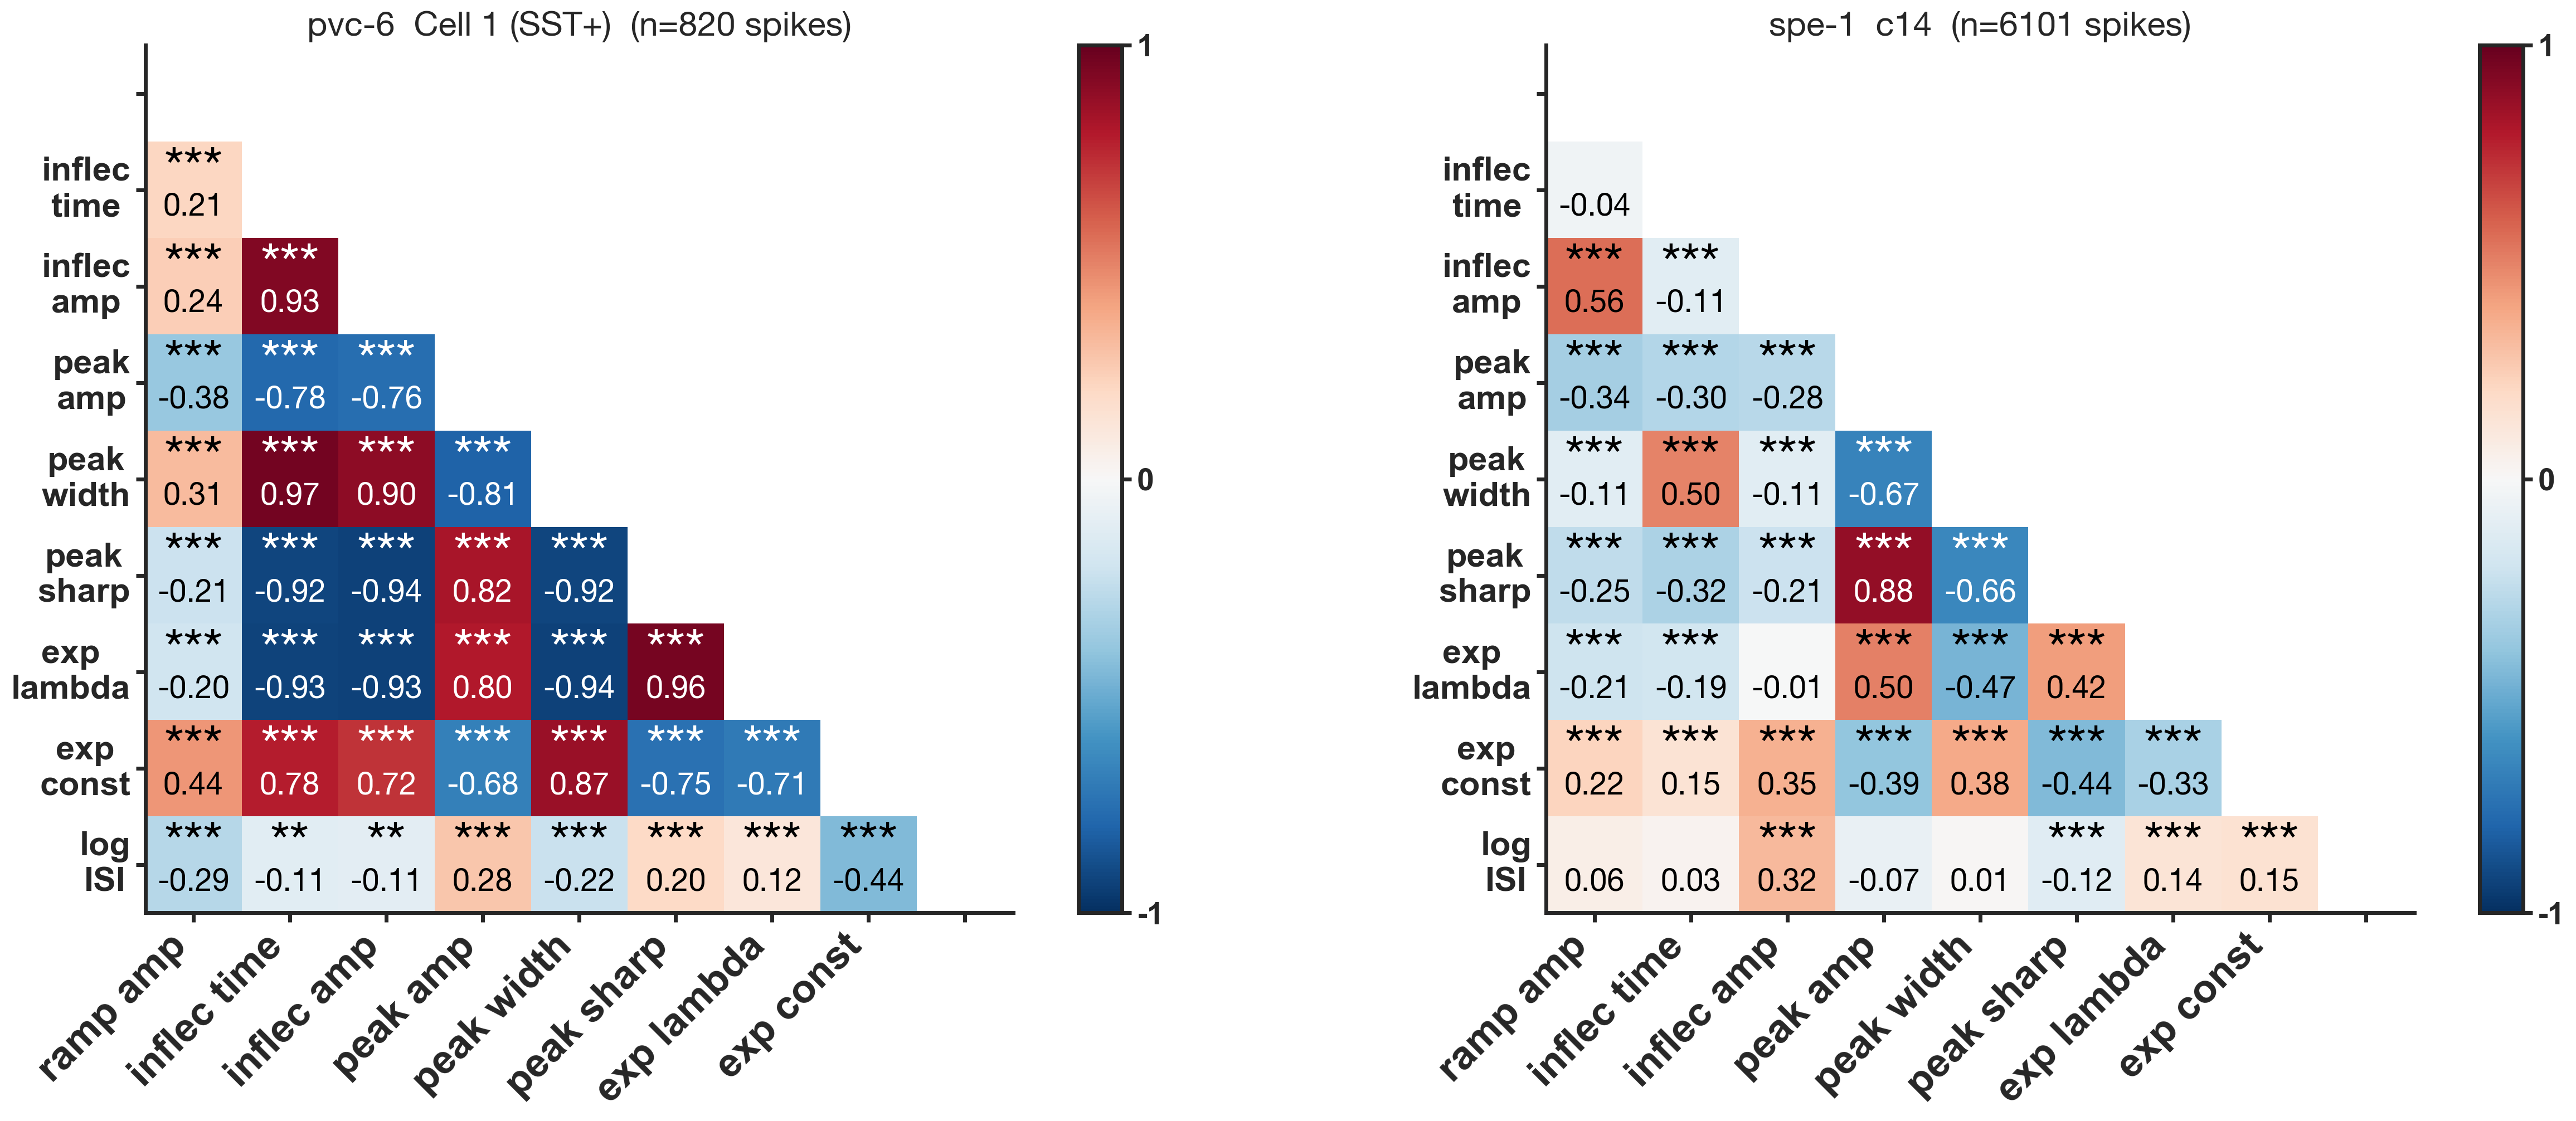

In [15]:
_c14_idx  = cids_all.index('c14')
df_c14    = dfs_all[_c14_idx]

fig_heatmaps = plot_two_corr_heatmaps(
    df_pvc6_c1, df_c14, SPK_FEATS,
    title_a=f'pvc-6  Cell 1 (SST+)  (n={len(df_pvc6_c1)} spikes)',
    title_b=f'spe-1  c14  (n={len(df_c14)} spikes)',
    figsize=(26, 10),
)

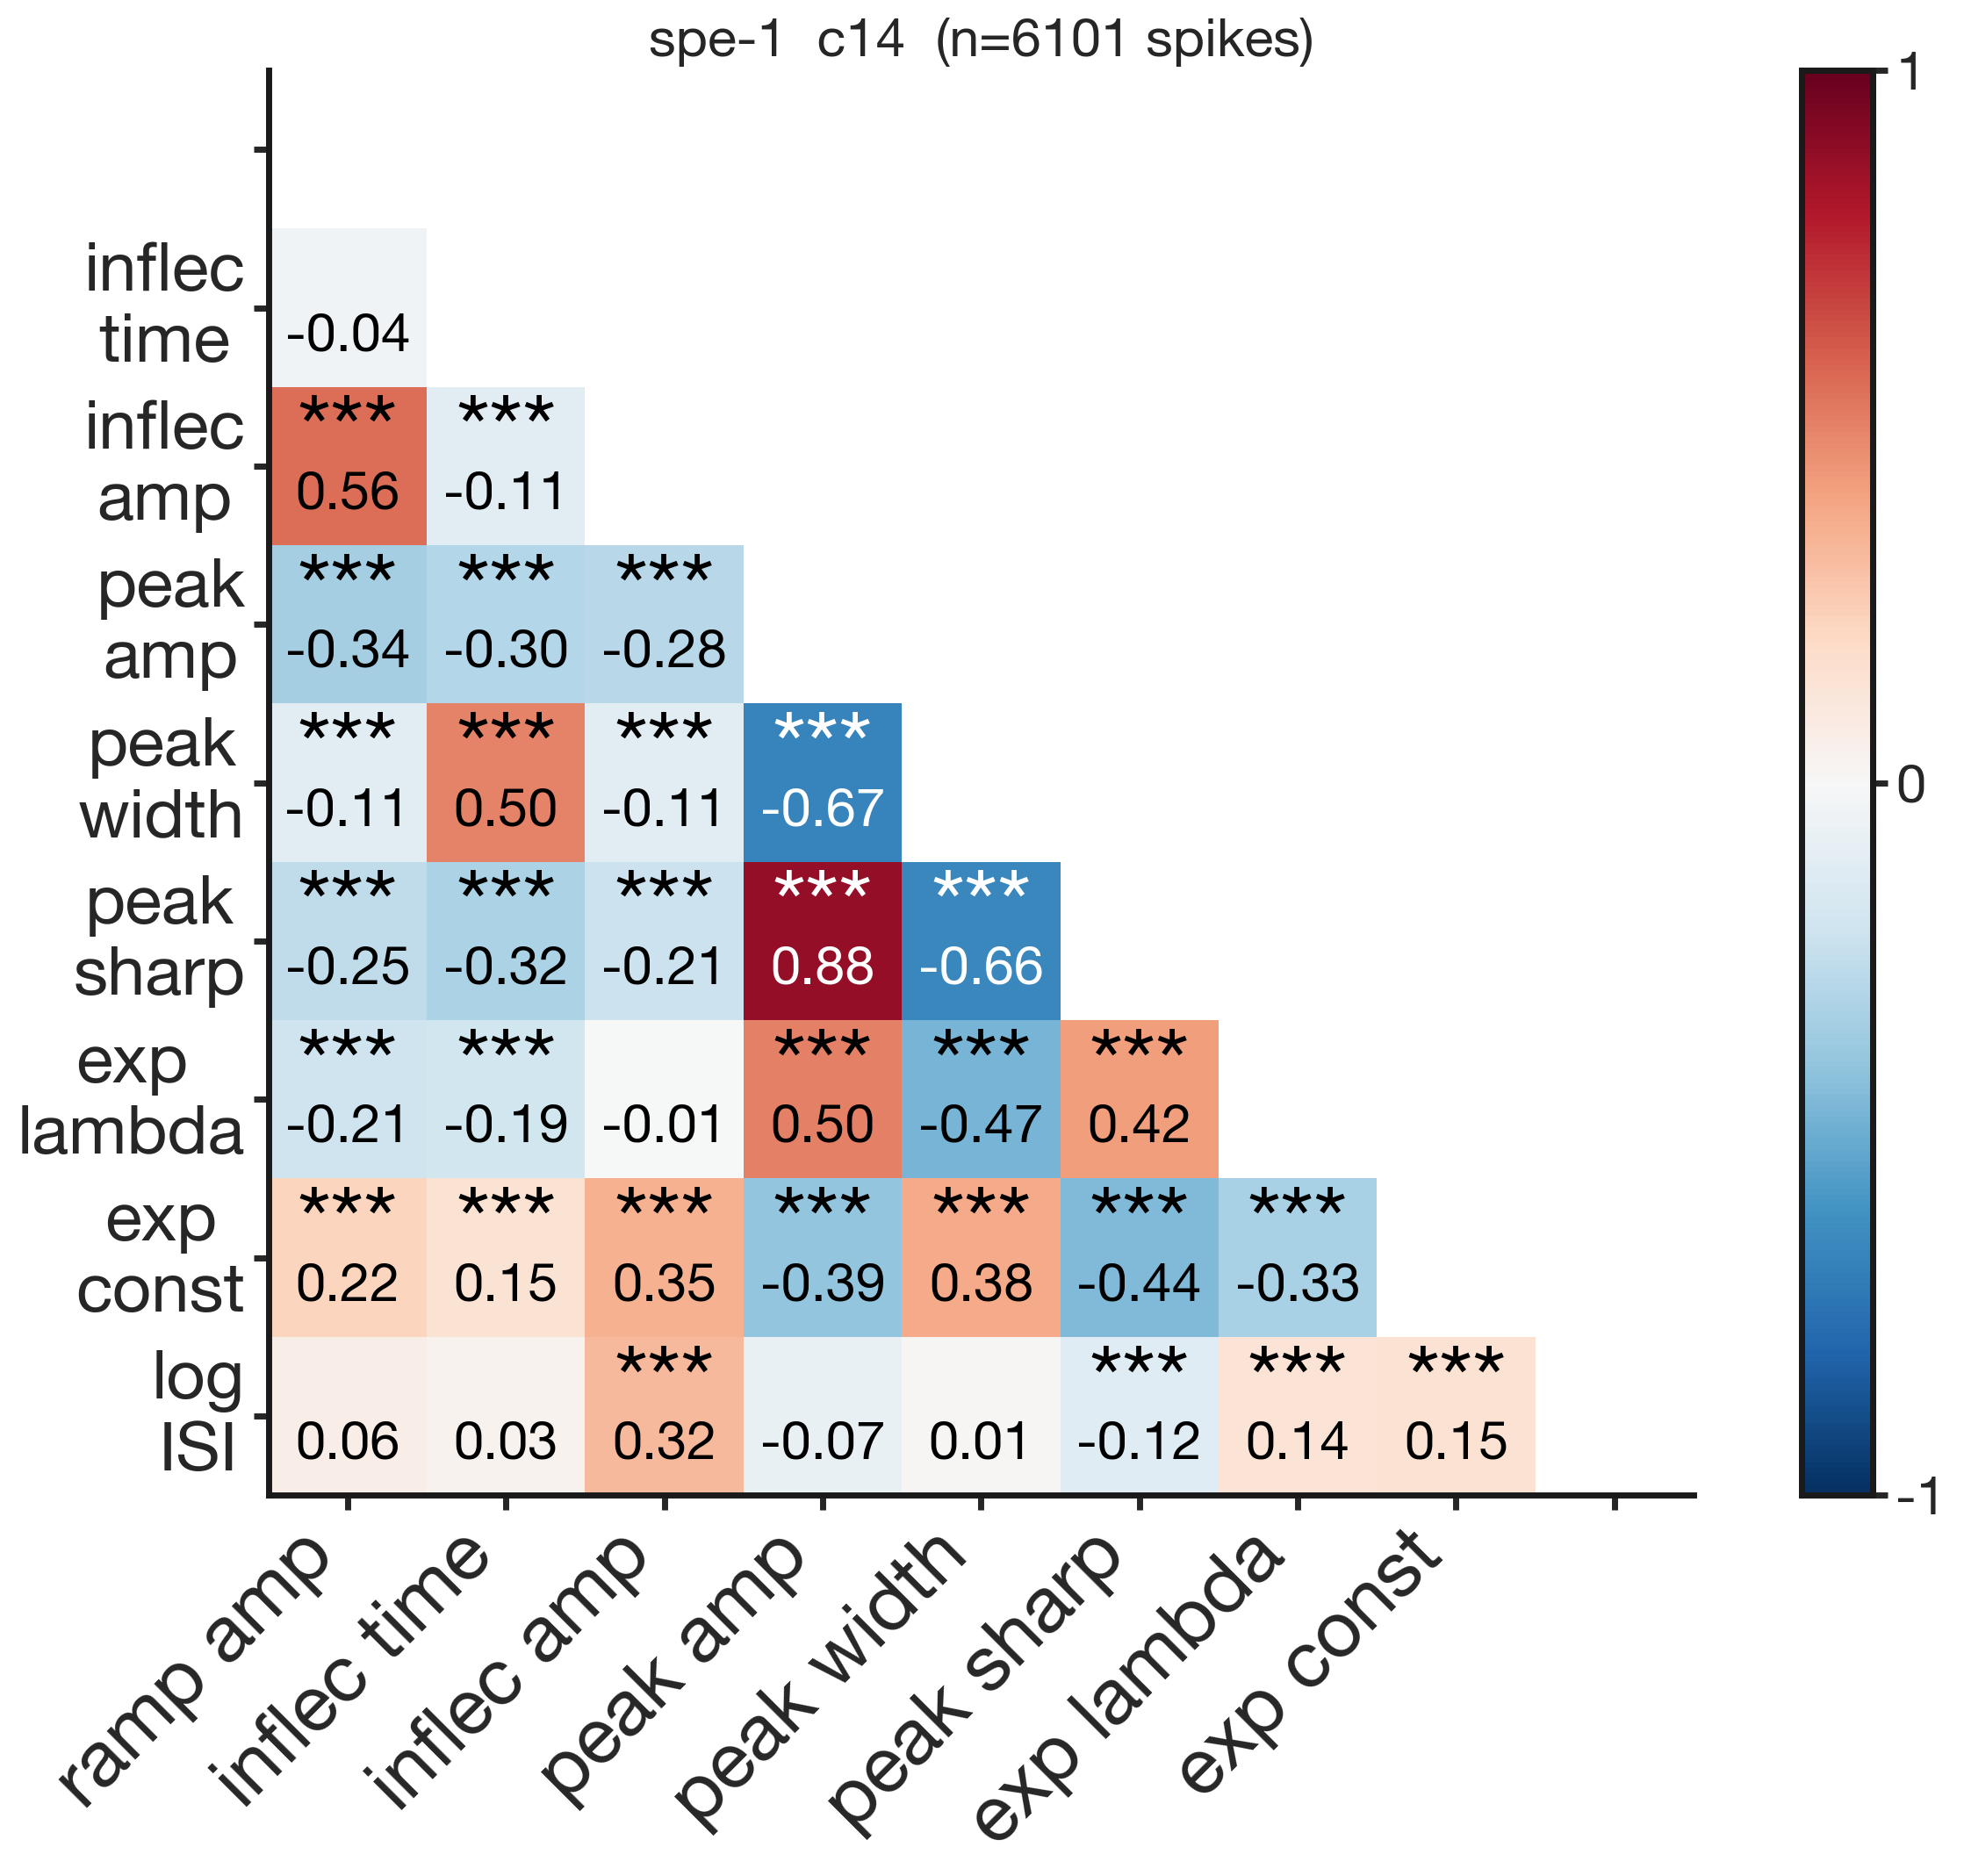

In [16]:
plot_corr_heatmap_only_spk(
    df_c14,
    SPK_FEATS,
    title=f'spe-1  c14  (n={len(df_c14)} spikes)',
)

### Decay correlation direction vs ridge R²

Does the direction of r(exp_lambda, peak_amp) relate to how well waveform features predict LFP state?

**Panel A**: scatter of r(exp_lambda, peak_amp) vs mean Waveform-only ridge R² across all LFP targets. Pearson r and Spearman ρ test whether the correlation direction or magnitude predicts ridge performance.

**Panel B**: bar count of direction agreement between the within-cell correlation sign (r) and the mean Decay λ ridge beta sign across targets. A Fisher's exact test checks whether cells that show positive exp_lambda→peak_amp correlations also drive exp_lambda→LFP effects in the same direction.

n cells merged (ridge + decay corr): 39


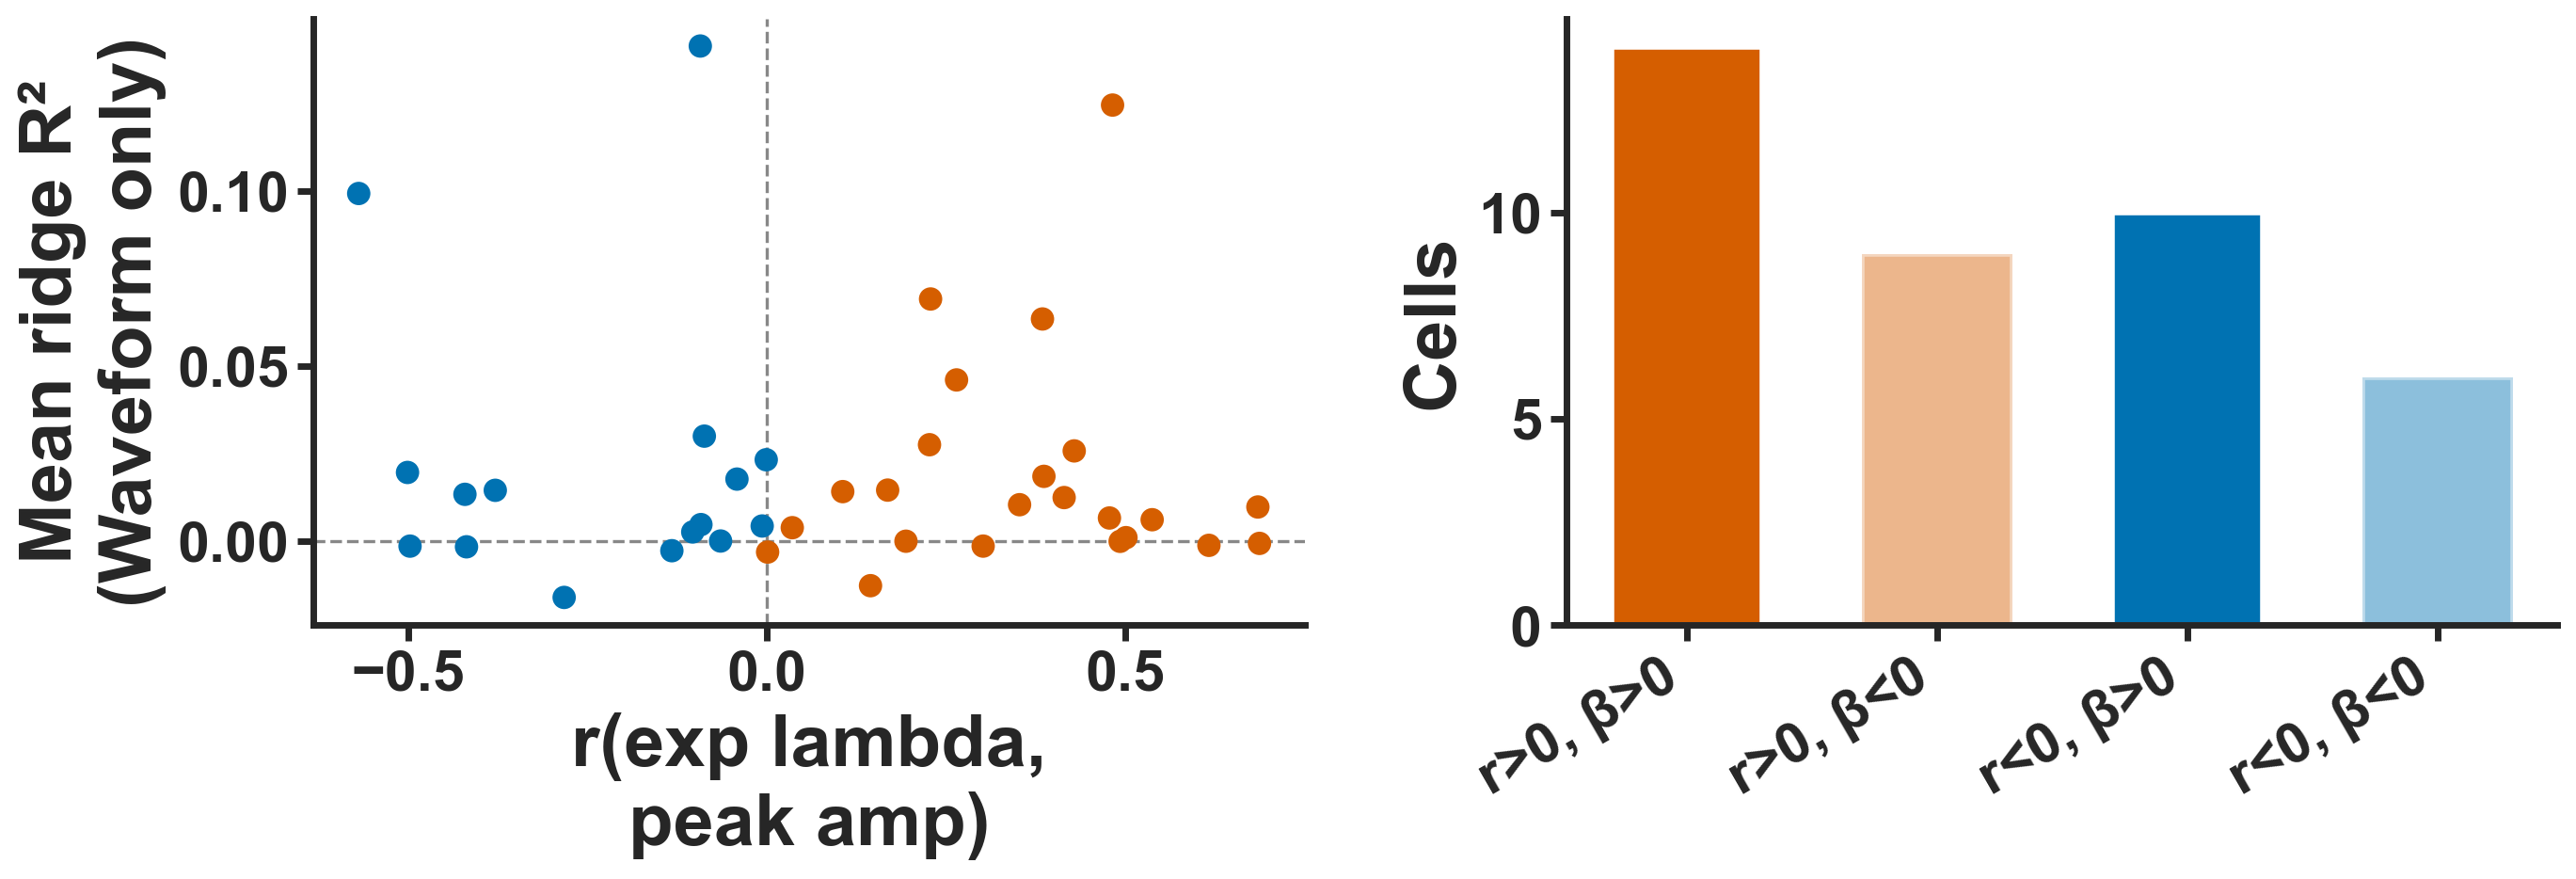

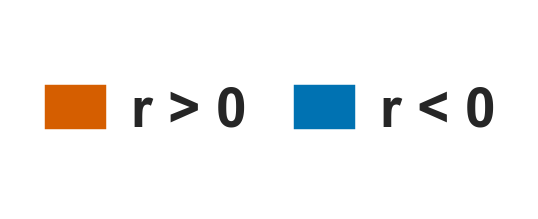

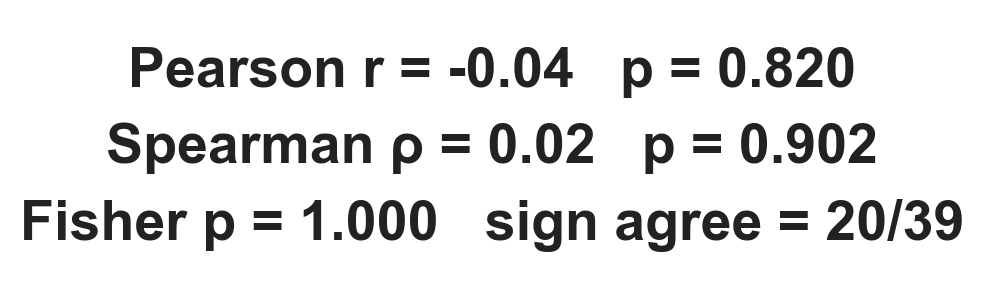

In [17]:
from spk_feat_cluster_comp_analysis import (
    compute_r2_vs_decay_corr,
    plot_r2_vs_decay_corr,
    plot_r2_vs_decay_corr_legend,
    plot_r2_vs_decay_corr_stats,
)

_POP_RIDGE_PKL = os.path.join(SPE1_PKL, 'ridge_regression_pickles', 'population_ridge_results.pkl')

df_r2_decay, _target_names = compute_r2_vs_decay_corr(
    df_corr_dir, _POP_RIDGE_PKL,
    predictor_set='Waveform only',
    decay_beta_label='Decay λ',
)
print(f"n cells merged (ridge + decay corr): {len(df_r2_decay)}")

fig_r2, _r, _p, _rho, _rho_p, _fe_p, _n_agree, _n_total = plot_r2_vs_decay_corr(
    df_r2_decay, fs_ax=28, fs_tk=22, lw_sp=2.5, figsize=(14, 5),
)

fig_r2_legend = plot_r2_vs_decay_corr_legend(fs=20, figsize=(3.0, 1.4))

fig_r2_stats = plot_r2_vs_decay_corr_stats(
    _r, _p, _rho, _rho_p, _fe_p, _n_agree, _n_total,
    fs=20, figsize=(5.0, 1.8),
)

### Exp decay fit quality vs correlation direction

Does the quality of the exponential decay fit to the spike waveform (mean per-spike R² across all spikes in a cell) explain the direction of r(exp_lambda, peak_amp)?

**Panel A**: scatter of mean exp fit R² vs r(exp_lambda, peak_amp). If poor fits produce noisy exp_lambda estimates, low-R² cells should cluster near r ≈ 0.

**Panel B**: mean exp fit R² split by positive vs negative correlation direction. A significant Mann-Whitney U would suggest fit quality drives the directional split.

n cells with exp fit R²: 43
mean across cells: 0.461


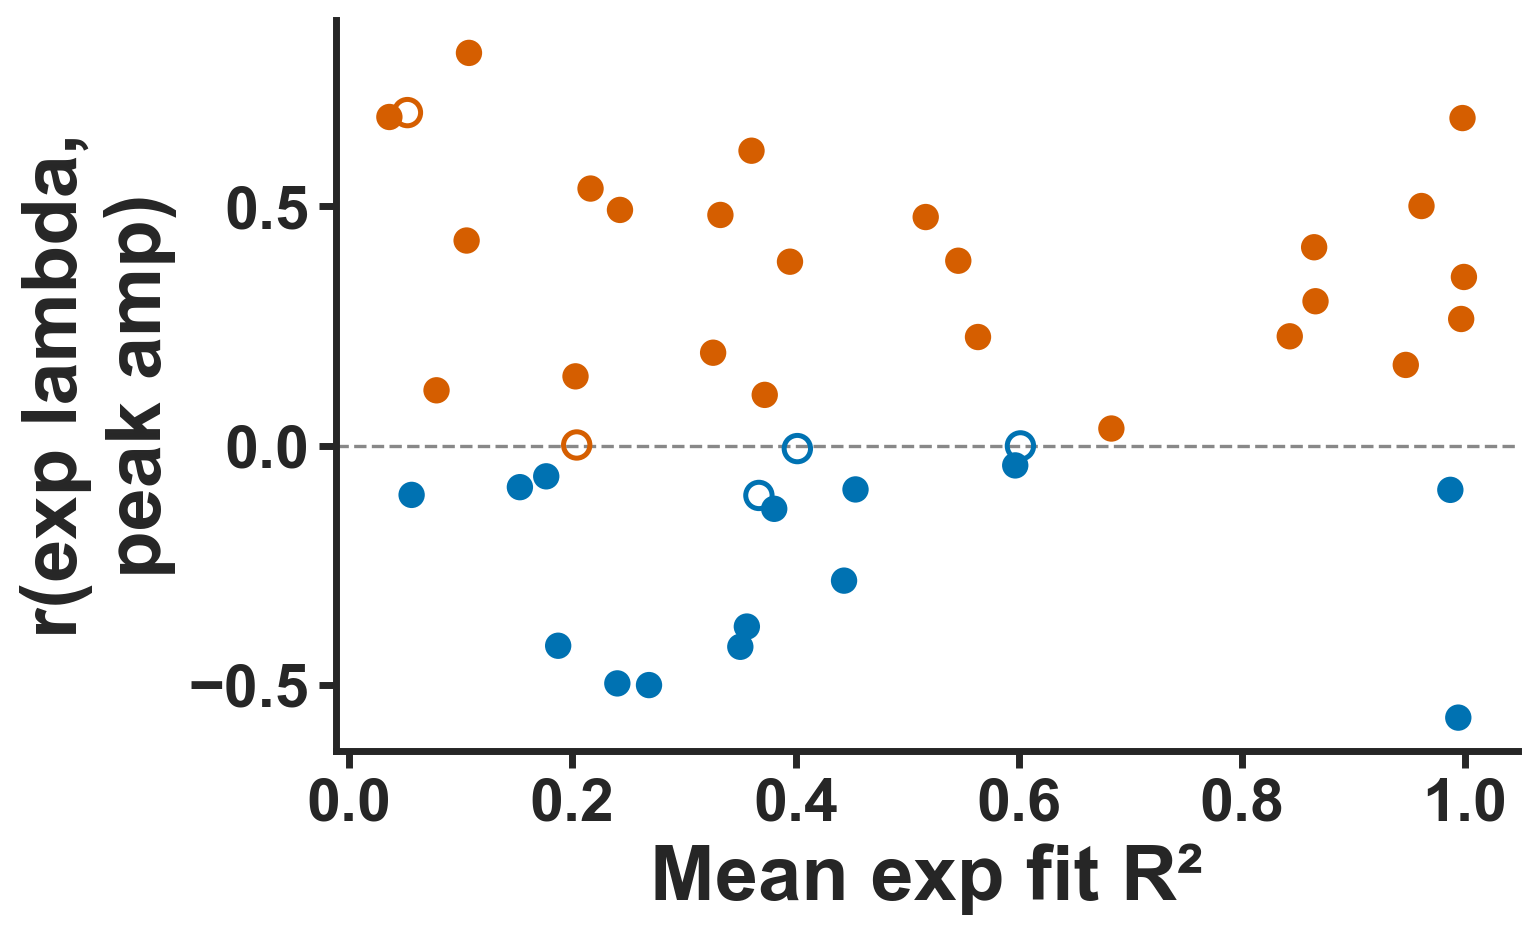

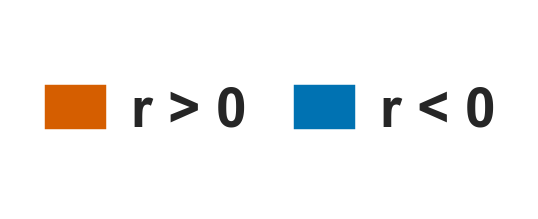

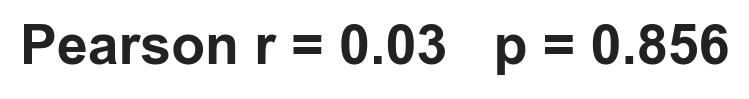

In [18]:
from spk_feat_cluster_comp_analysis import (
    compute_exp_fit_r2_per_cell,
    plot_exp_fit_r2_vs_decay_corr,
    plot_exp_fit_r2_legend,
    plot_exp_fit_r2_stats,
)

_SPIKE_FIT_DIR = os.path.join(SPE1_PKL, 'spike_fit_pickles')

df_fit_r2 = compute_exp_fit_r2_per_cell(cids_all, _SPIKE_FIT_DIR)
print(f"n cells with exp fit R²: {len(df_fit_r2)}")
print(f"mean across cells: {df_fit_r2['mean_r2_exp'].mean():.3f}")

fig_fit_r2, df_fit_merged, _r, _p = plot_exp_fit_r2_vs_decay_corr(
    df_corr_dir, df_fit_r2,
    fs_ax=28, fs_tk=22, lw_sp=2.5, figsize=(8, 5),
)

fig_fit_r2_legend = plot_exp_fit_r2_legend(fs=20, figsize=(3.0, 1.4))

fig_fit_r2_stats = plot_exp_fit_r2_stats(_r, _p, fs=20, figsize=(4.0, 0.8))

---
## Preceding-ISI version (spe-1 only)

Added in response to reviewer Gert Cauwenberghs (via Brad): panels 2-4 above use `log_isi` (time to the next spike), giving the forward-looking result "APs that decayed faster tended to be followed by shorter inter-spike intervals" - kept as-is above, since that's a real and different claim (waveform predicting subsequent excitability). Below is the backward direction: does `log_isi_prev` (time since the preceding spike) correlate with waveform the same way?

**spe-1 only** - pvc-6's spike tables have no timestamp column to reconstruct `log_isi_prev` from, and per the original scope here pvc-6 is meant to stay as forward-only counter-evidence (waveform prediction of input amplitude out to 500ms pre-spike, on a slower timescale than refractoriness could explain), not be extended with a preceding-ISI panel.

In [19]:
SPK_FEATS_PREV = SPK_FEATS + ['log_isi_prev']

### 2b. spe-1 — putative IN, preceding ISI

IN cells used: 5


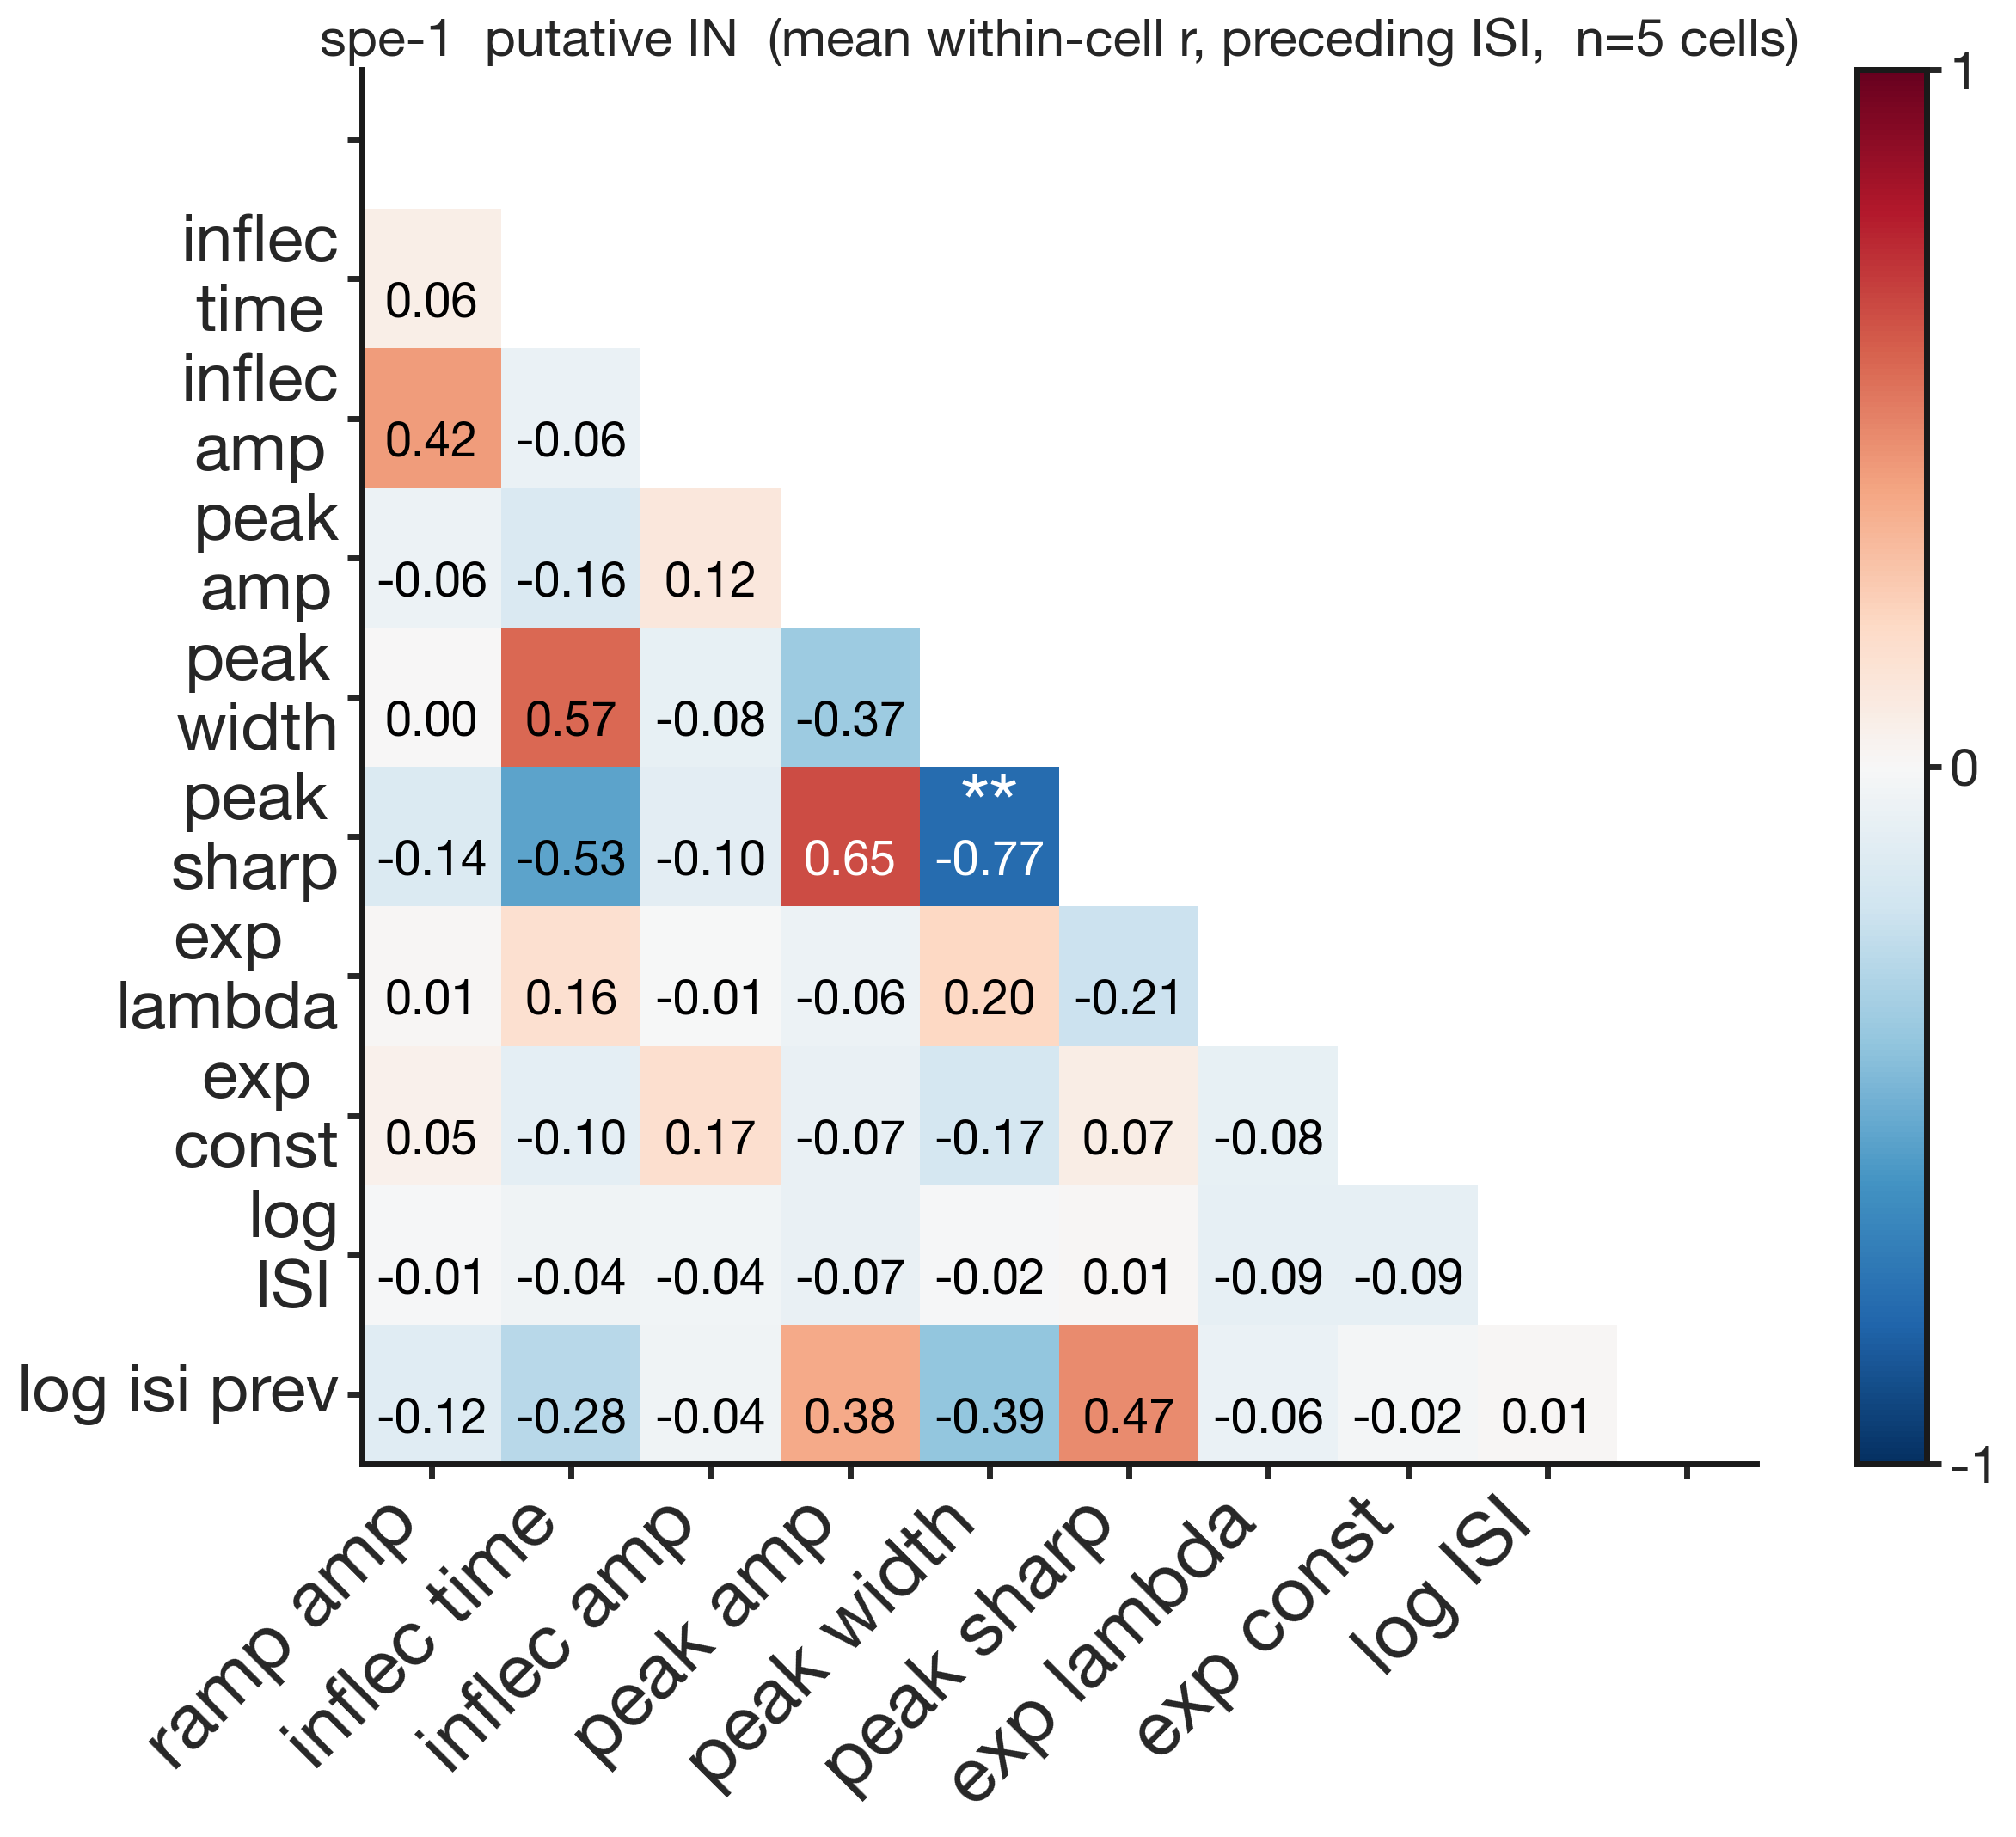

In [20]:
mean_r_in_prev, pval_in_prev, n_in_prev = compute_within_cell_avg_corr(dfs_in, SPK_FEATS_PREV)
print(f'IN cells used: {n_in_prev}')
plot_avg_corr_heatmap(
    mean_r_in_prev, pval_in_prev, SPK_FEATS_PREV,
    title=f'spe-1  putative IN  (mean within-cell r, preceding ISI,  n={n_in_prev} cells)'
)

### 3b. spe-1 — putative PC, preceding ISI

PC cells used: 37


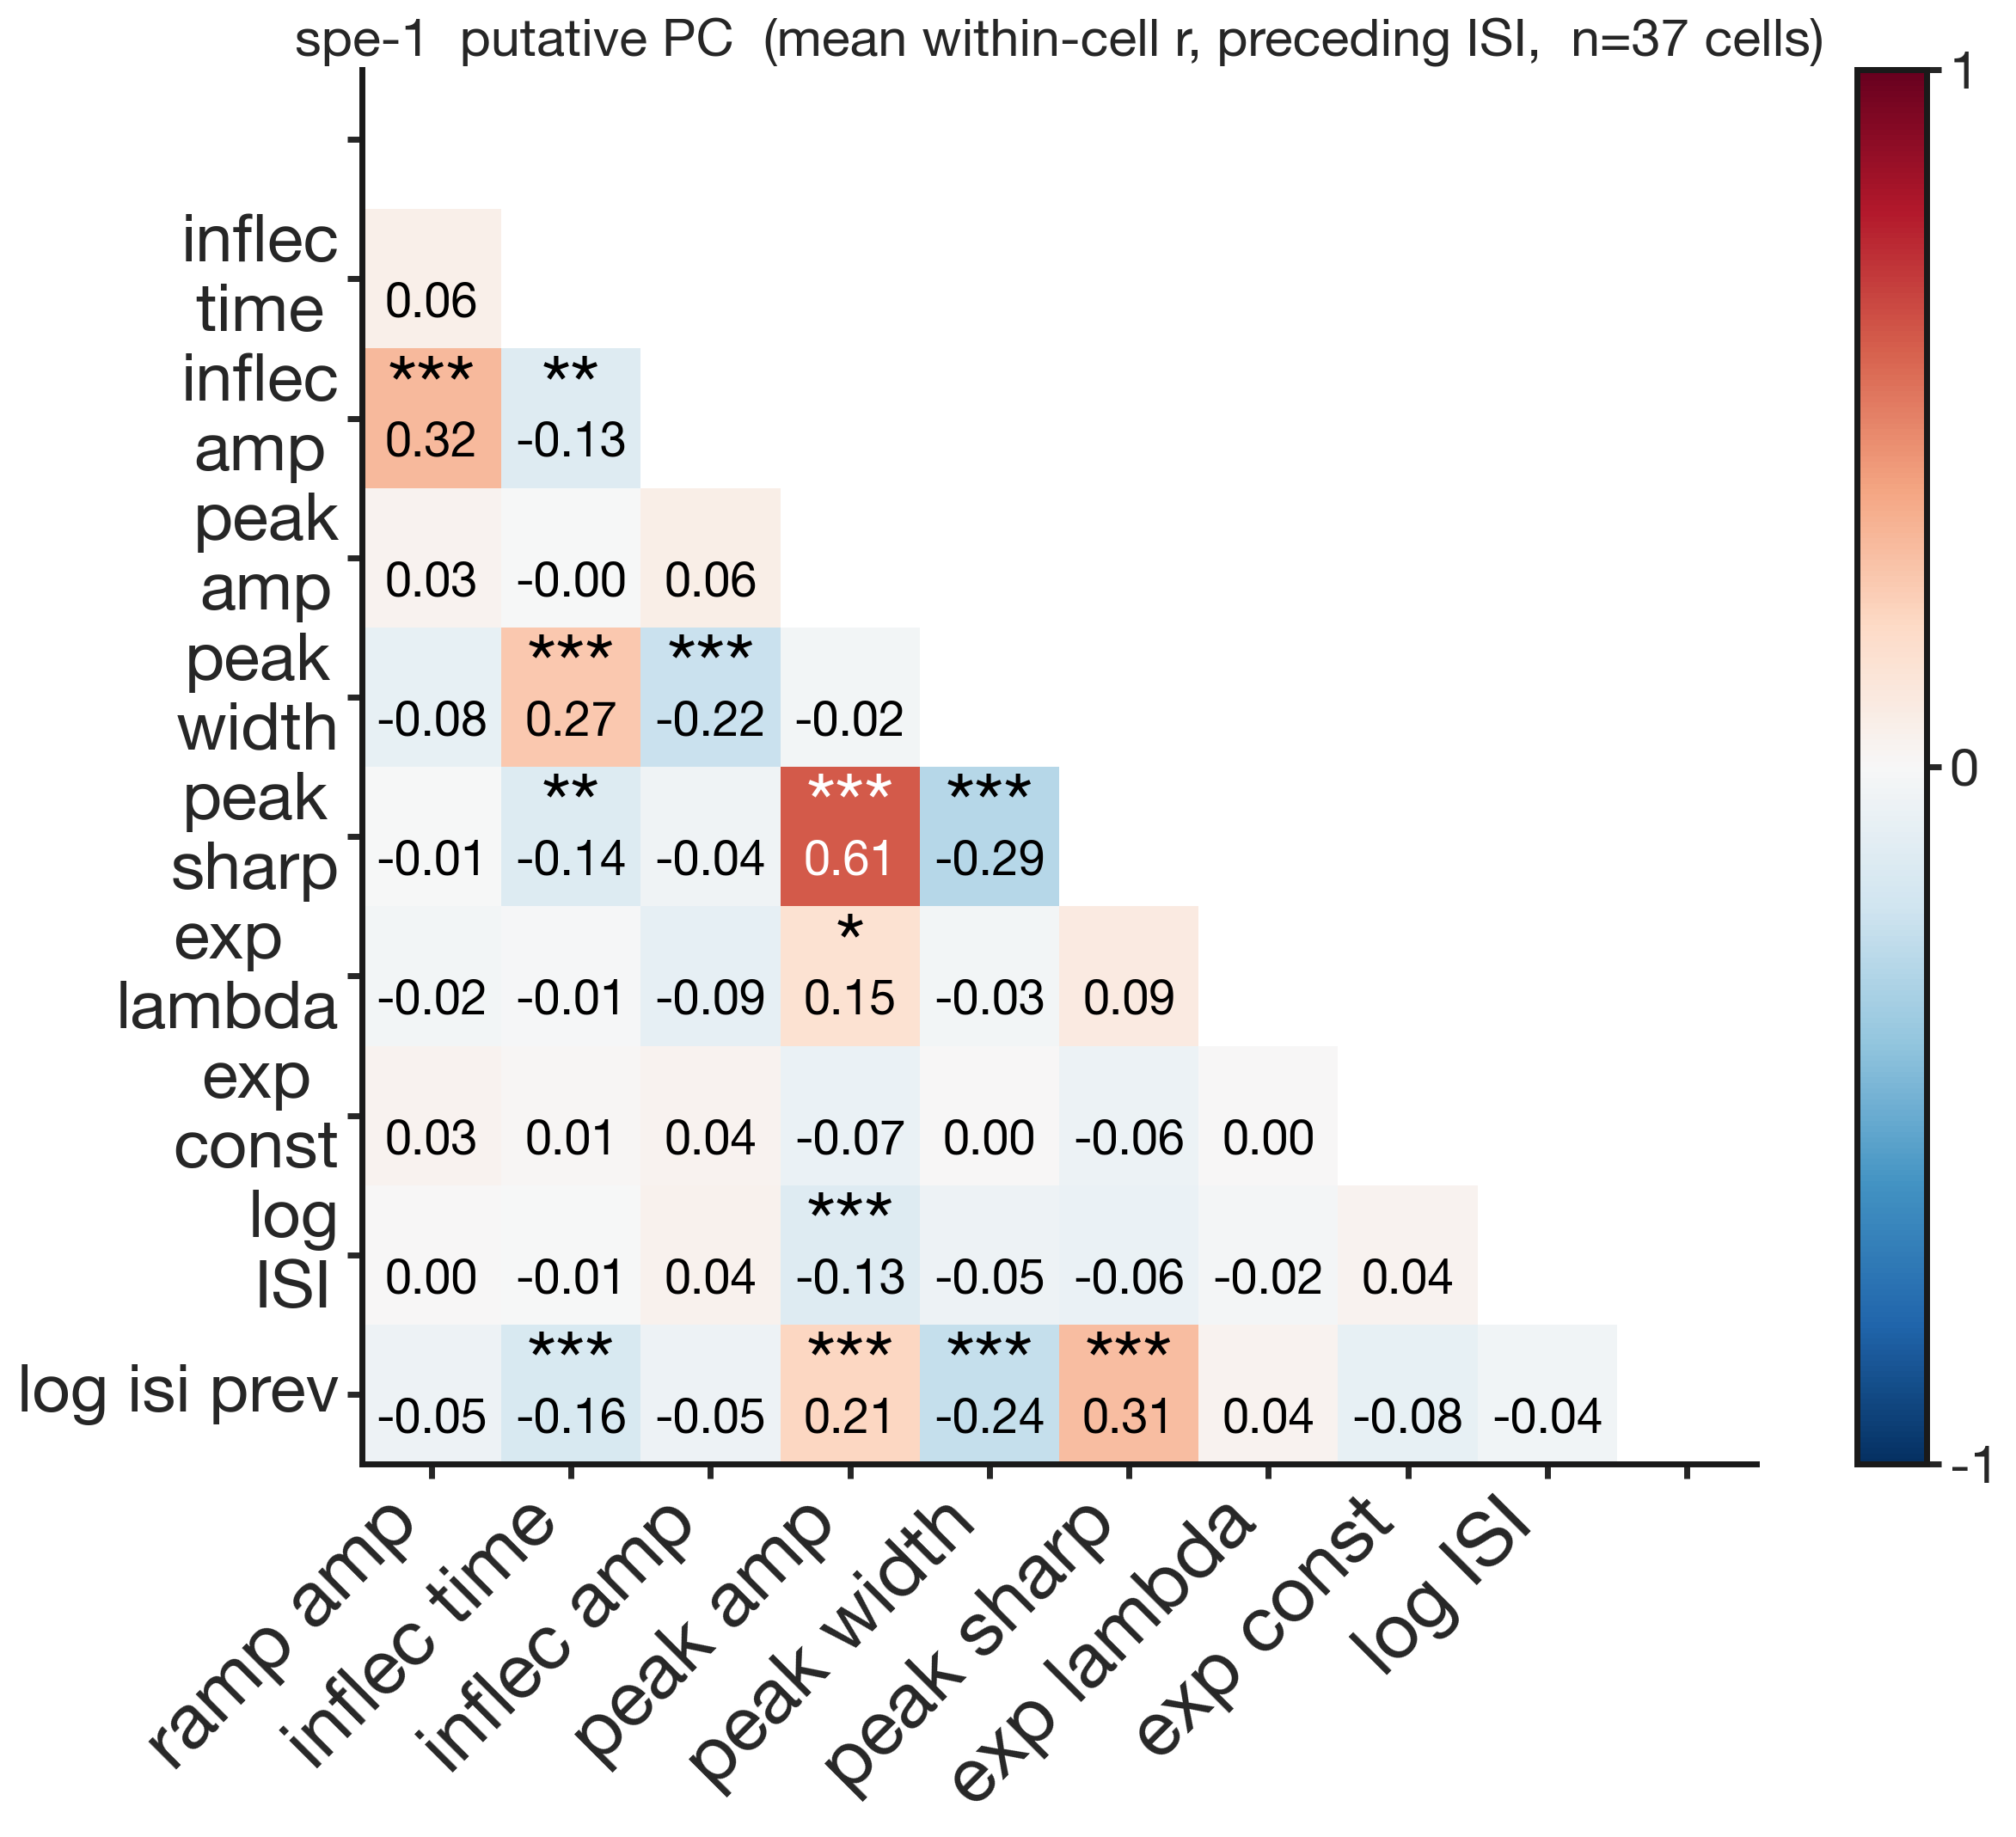

In [21]:
mean_r_pc_prev, pval_pc_prev, n_pc_prev = compute_within_cell_avg_corr(dfs_pc, SPK_FEATS_PREV)
print(f'PC cells used: {n_pc_prev}')
plot_avg_corr_heatmap(
    mean_r_pc_prev, pval_pc_prev, SPK_FEATS_PREV,
    title=f'spe-1  putative PC  (mean within-cell r, preceding ISI,  n={n_pc_prev} cells)'
)

### 4b. spe-1 — all cells, preceding ISI

spe-1 cells used: 42


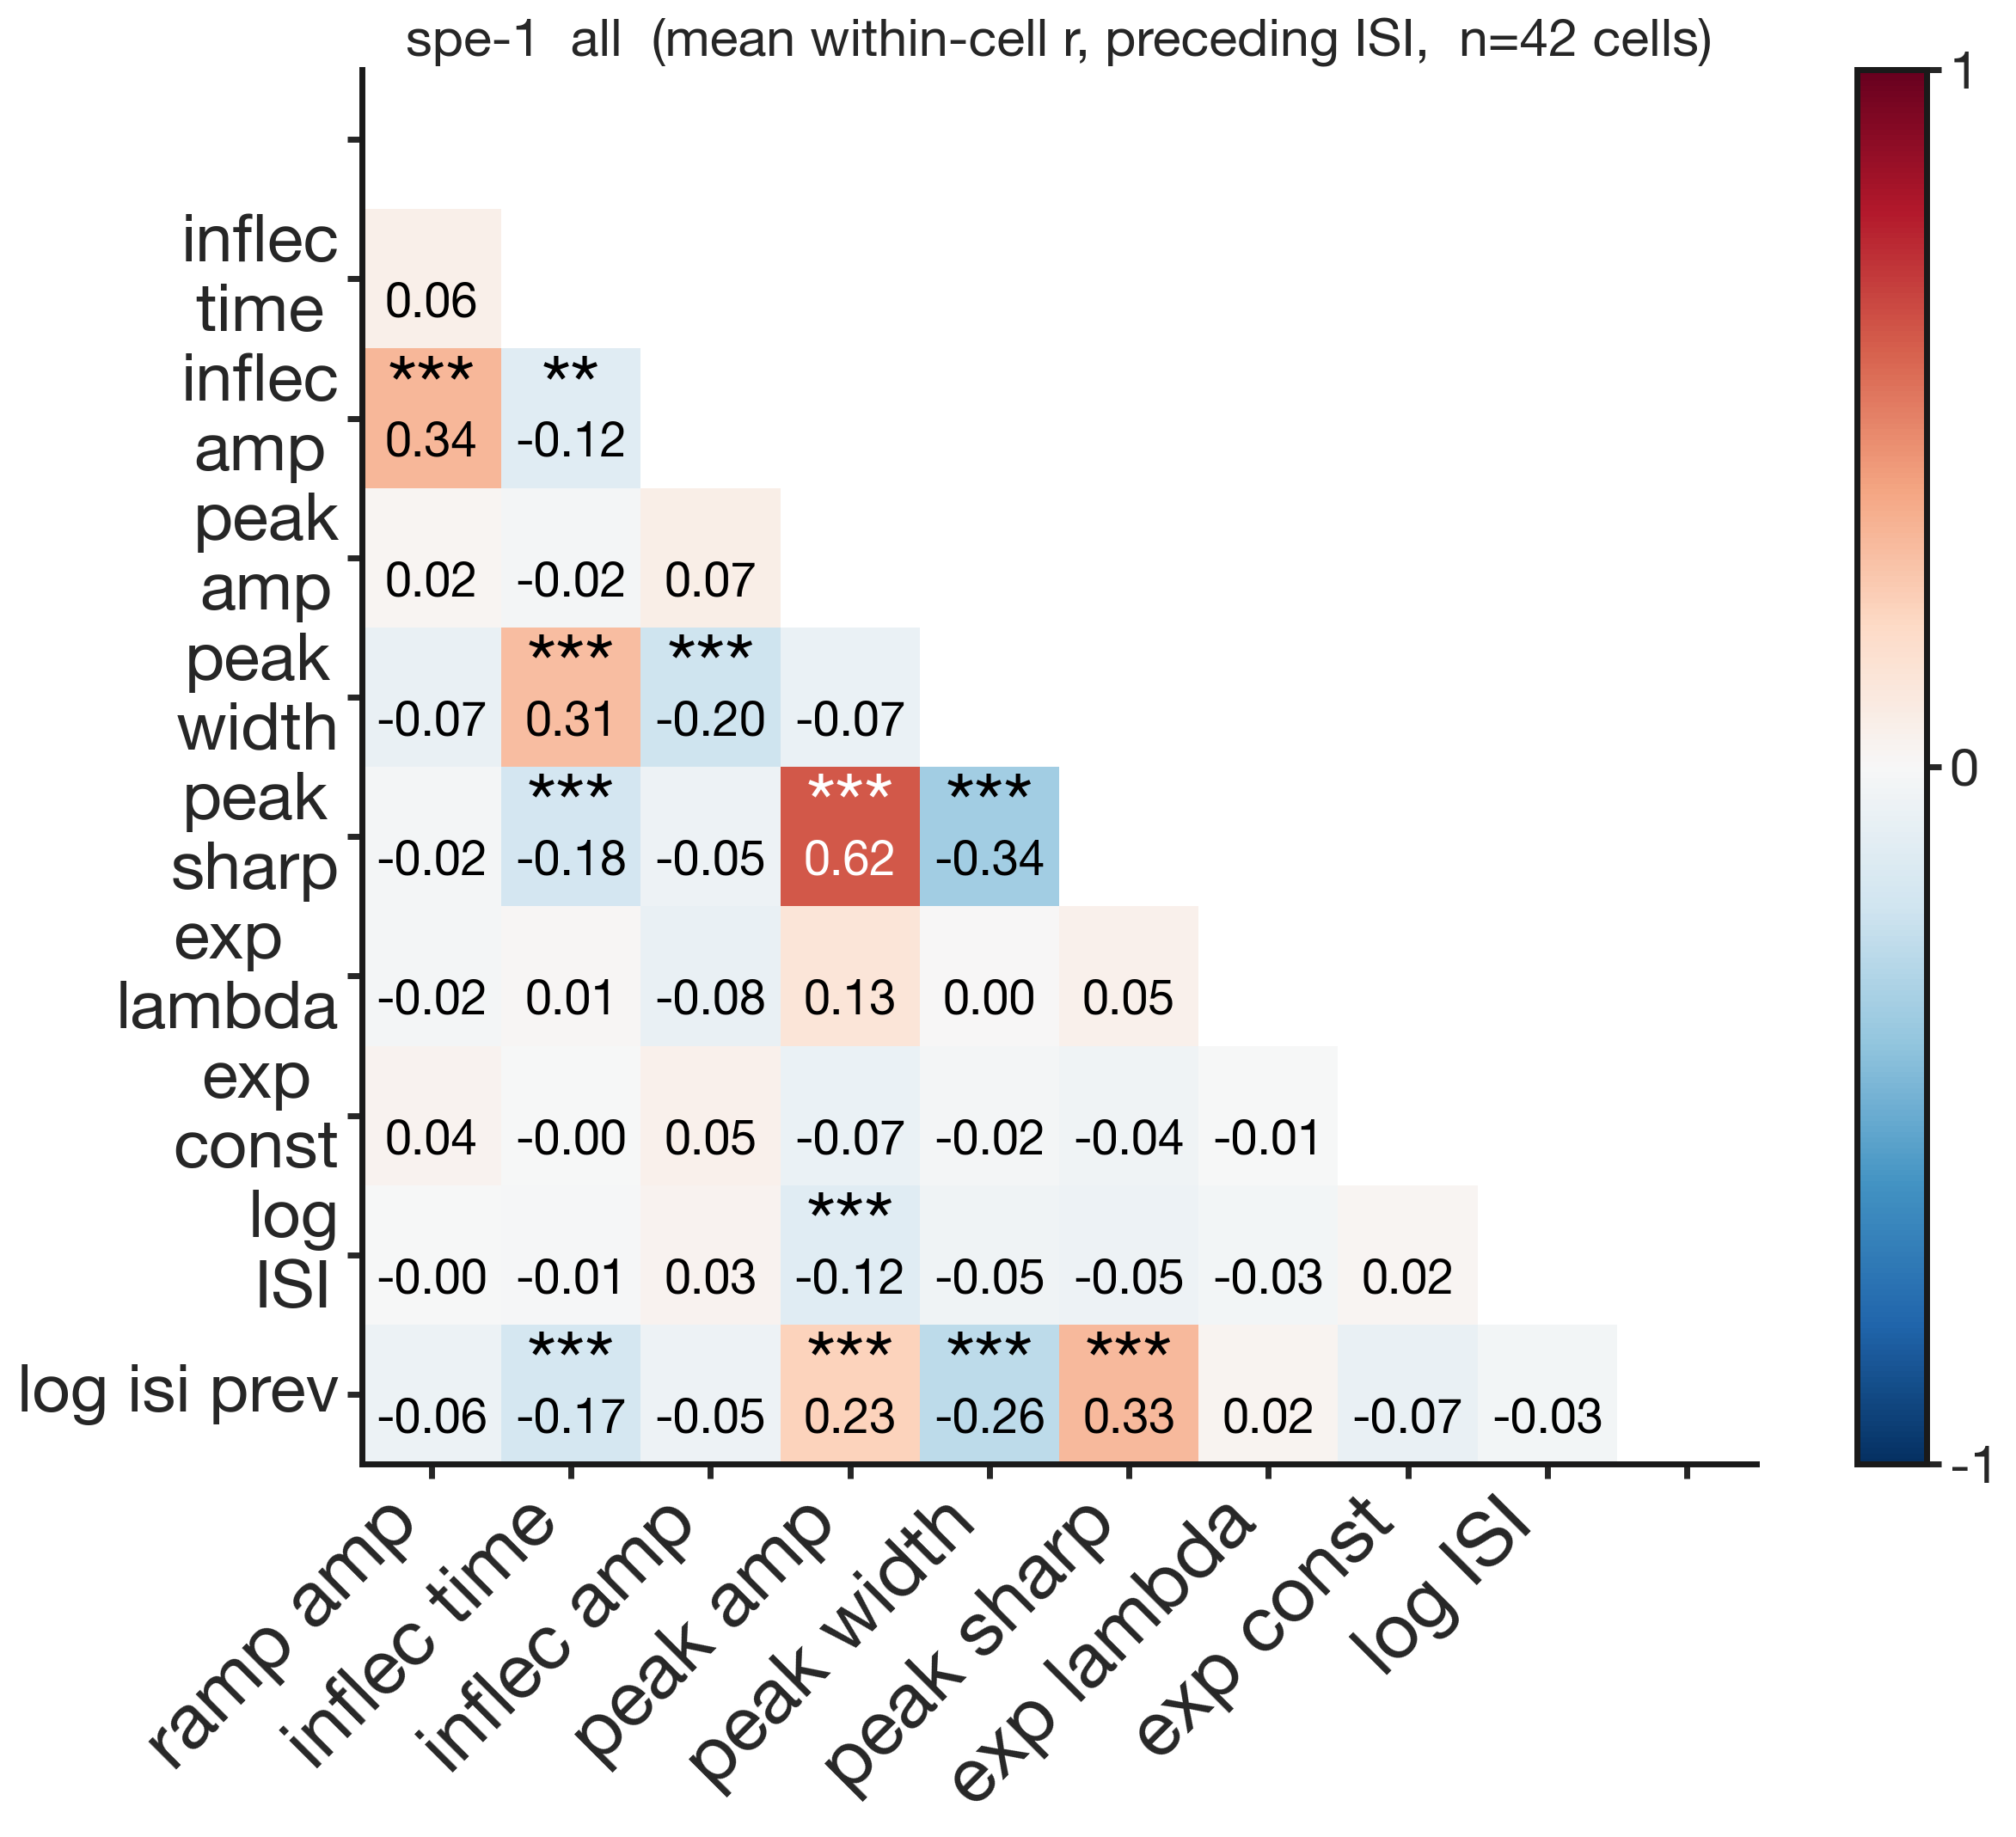

In [22]:
mean_r_spe1_prev, pval_spe1_prev, n_spe1_prev = compute_within_cell_avg_corr(dfs_all, SPK_FEATS_PREV)
print(f'spe-1 cells used: {n_spe1_prev}')
plot_avg_corr_heatmap(
    mean_r_spe1_prev, pval_spe1_prev, SPK_FEATS_PREV,
    title=f'spe-1  all  (mean within-cell r, preceding ISI,  n={n_spe1_prev} cells)'
)

In [23]:
# ── Compare: does the exp_lambda <-> ISI correlation direction/magnitude change? ──
feat_names = SPK_FEATS_PREV
i_lambda = feat_names.index('exp_lambda')
i_next   = feat_names.index('log_isi')
i_prev   = feat_names.index('log_isi_prev')

for label, mean_r, pval, n in [
    ('IN',  mean_r_in_prev,   pval_in_prev,   n_in_prev),
    ('PC',  mean_r_pc_prev,   pval_pc_prev,   n_pc_prev),
    ('all', mean_r_spe1_prev, pval_spe1_prev, n_spe1_prev),
]:
    r_next = mean_r[i_lambda, i_next]
    r_prev = mean_r[i_lambda, i_prev]
    print(f'{label:>4s} (n={n:2d} cells):  '
          f'r(exp_lambda, next-ISI) = {r_next:+.3f}   '
          f'r(exp_lambda, preceding-ISI) = {r_prev:+.3f}')

  IN (n= 5 cells):  r(exp_lambda, next-ISI) = -0.088   r(exp_lambda, preceding-ISI) = -0.063
  PC (n=37 cells):  r(exp_lambda, next-ISI) = -0.023   r(exp_lambda, preceding-ISI) = +0.036
 all (n=42 cells):  r(exp_lambda, next-ISI) = -0.030   r(exp_lambda, preceding-ISI) = +0.025
